<a href="https://colab.research.google.com/github/Saba-Sabzevari/Precision_Agriculture_Soil_Health_Classification_System/blob/main/Precision_Agriculture_Soil_Health_Classification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Precision Agriculture Soil Health Classification System

## Project Overview
- **Course:** Pattern Recognition (M.Sc.) - WS25
- **Group Members:**
  - Student 1 (Technical Lead): Saba Sabzevari
  - Student 1 (Figures & Presentation): Saba Sabzevari
  - Student 2 (Report & Storytelling): Isha
- **Dataset:** Kaggle Comprehensive Soil Classification Dataset
- **Research Questions:** 5 (RQ1-RQ5)

---

## List of Figures and Tables Generated by This Notebook

### Figures (24 PDFs)

#### Methodology Section
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 1 | `dataset_samples.pdf` | Sample images from each of the 7 soil classes |
| Fig 2 | `dataset_distribution.pdf` | Bar chart showing class distribution with train/val/test split |

#### RQ1 - CNN Architecture Comparison
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 3 | `RQ1/RQ1_Fig1.pdf` | Confusion Matrix - ResNet50 |
| Fig 4 | `RQ1/RQ1_Fig2.pdf` | Confusion Matrix - EfficientNet-B3 |
| Fig 5 | `RQ1/RQ1_Fig3.pdf` | Training Curves (Loss & Accuracy) |
| Fig 6 | `RQ1/RQ1_Fig4.pdf` | Confusion Matrix - Vision Transformer (ViT) |
| Fig 7 | `RQ1/RQ1_Fig5.pdf` | Per-Class F1-Score Comparison |
| Fig 8 | `RQ1/RQ1_Fig6.pdf` | ROC Curves for all 7 classes |

#### RQ2 - Metalearner Ensemble
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 9 | `RQ2/RQ2_Fig1.pdf` | Confusion Matrix - Metalearner |
| Fig 10 | `RQ2/RQ2_Fig2.pdf` | F1-Score Comparison (all models) |
| Fig 11 | `RQ2/RQ2_Fig3.pdf` | Base Learner Performance Comparison |

#### RQ3 - Hybrid Expert System
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 12 | `RQ3/RQ3_Fig1.pdf` | Confusion Matrix - Hybrid System |
| Fig 13 | `RQ3/RQ3_Fig2.pdf` | Accuracy Comparison Bar Chart |
| Fig 14 | `RQ3/RQ3_Fig3.pdf` | Rule Application Distribution |

#### RQ4 - Explainability
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 15 | `RQ4/RQ4_Fig1.pdf` | GradCAM Visualization - Sample 1 |
| Fig 16 | `RQ4/RQ4_Fig2.pdf` | GradCAM Visualization - Sample 2 |
| Fig 17 | `RQ4/RQ4_Fig3.pdf` | GradCAM Visualization - Sample 3 |
| Fig 18 | `RQ4/RQ4_Fig4.pdf` | SHAP Summary Plot |
| Fig 19 | `RQ4/RQ4_Fig5.pdf` | SHAP Top 10 Features Bar Plot |

#### RQ5 - Deployment Feasibility
| Figure | Filename | Description |
|--------|----------|-------------|
| Fig 20 | `RQ5/RQ5_Fig1.pdf` | Inference Time Comparison |
| Fig 21 | `RQ5/RQ5_Fig2.pdf` | Model Size Comparison |
| Fig 22 | `RQ5/RQ5_Fig3.pdf` | Efficiency vs Accuracy Trade-off |
| Fig 23 | `RQ5/RQ5_Fig4.pdf` | Calibration/Reliability Diagram |

---

### Tables (8 Excel Files)

#### Methodology Section
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 1 | `network_configuration.xlsx` | Network configuration parameters |

#### RQ1 - CNN Architecture Comparison
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 2 | `RQ1/RQ1_Tab1.xlsx` | CNN Comparison Results |

#### RQ2 - Metalearner Ensemble
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 3 | `RQ2/RQ2_Tab1.xlsx` | Metalearner vs CNN Comparison |

#### RQ3 - Hybrid Expert System
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 4 | `RQ3/RQ3_Tab1.xlsx` | Rule-based Integration Results |
| Tab 5 | `RQ3/RQ3_Tab2.xlsx` | Ablation Study Results |

#### RQ4 - Explainability
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 6 | `RQ4/RQ4_Tab1.xlsx` | Explainability Methods Summary |

#### RQ5 - Deployment Feasibility
| Table | Filename | Description |
|-------|----------|-------------|
| Tab 7 | `RQ5/RQ5_Tab1.xlsx` | Deployment Metrics |
| Tab 8 | `RQ5/RQ5_Tab2.xlsx` | Final Results (all models) |

---

### Manual Creation Required
| Type | Description |
|------|-------------|
| Figure | Methodology Workflow Diagram (create in PowerPoint) |
| Table | Literature Review Summary Table (fill content in Excel) |
|Comparison with Literature Table|Must fill content manually in Excel|

---

## Summary
- **Total Figures:** 24 PDFs
- **Total Tables:** 8 Excel files
- **Manual Items:** 2 (workflow diagram + literature table)

**Project Steps**


1. Environment Setup & Library Configuration2. Dataset Acquisition & Initial Loading
3. Data Preprocessing Pipeline & Augmentation Strategies
4. Deep Learning Architecture Implementation
5. Model Training & Optimization
6. Baseline Performance Evaluation
7. Multi-Scale Feature Extraction
8. Ensemble Metalearner Development
9. Knowledge-Based Rule Engine Design
10. Hybrid Expert System Integration
11. Systematic Ablation Analysis
12. Comprehensive Results & Performance Visualization


1. Environment Setup & Library Configuration

1.1 Project Header & Setup

In [ ]:
# C1: Project Header & Setup
"""
PRECISION AGRICULTURE SOIL HEALTH CLASSIFICATION SYSTEM

Course: Pattern Recognition (M.Sc.) - WS25
Group Members:
  - Student 1 (Technical Lead): Saba Sabzevari
  - Student 1 (Figures & Presentation): Saba Sabzevari
  - Student 2 (Report & Storytelling): Isha

Project: Hybrid Expert System for Soil Type Classification
Dataset: Kaggle Comprehensive Soil Classification Dataset
Research Questions: 5 (RQ1-RQ5)
"""

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project paths
import os
PROJECT_ROOT = '/content/drive/MyDrive/Soil_Health_Classification_Phase2'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/figures', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/tables', exist_ok=True)

# Create RQ folders
for i in range(1, 6):
    os.makedirs(f'{PROJECT_ROOT}/figures/RQ{i}', exist_ok=True)
    os.makedirs(f'{PROJECT_ROOT}/tables/RQ{i}', exist_ok=True)

print(" Project structure created successfully")
print(f" Project root: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Project structure created successfully
 Project root: /content/drive/MyDrive/Soil_Health_Classification_Phase2


1.2 Import libraries

In [ ]:
# C2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import cv2
import pickle
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.83 GB


1.3 Configuration for CPU optimization

In [ ]:
# C3: Configuration for CPU optimization
CONFIG = {
    'device': device,
    'batch_size': 32,  # Smaller batch for CPU 16 --> 32
    'num_workers': 2,  # CPU workers
    'img_size': 224,  # Standard size
    'epochs': 20,  # Reduced for CPU
    'learning_rate': 1e-3,
    'num_classes': 7,
    'checkpoint_dir': f'{PROJECT_ROOT}/checkpoints',
    'figures_dir': f'{PROJECT_ROOT}/figures',
    'tables_dir': f'{PROJECT_ROOT}/tables',
}

# Soil classes
SOIL_CLASSES = [
    'Alluvial', 'Black', 'Clay', 'Laterite', 'Peat', 'Red', 'Yellow'
]

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  device: cuda
  batch_size: 32
  num_workers: 2
  img_size: 224
  epochs: 20
  learning_rate: 0.001
  num_classes: 7
  checkpoint_dir: /content/drive/MyDrive/Soil_Health_Classification_Phase2/checkpoints
  figures_dir: /content/drive/MyDrive/Soil_Health_Classification_Phase2/figures
  tables_dir: /content/drive/MyDrive/Soil_Health_Classification_Phase2/tables


2. Dataset Acquisition & Initial Loading

2.1 Extract dataset from existing zip file

In [ ]:
# C4: Extract and locate dataset
import zipfile
from pathlib import Path

DATASET_DIR = f'{PROJECT_ROOT}/dataset'
ZIP_FILE = f'{PROJECT_ROOT}/comprehensive-soil-classification-datasets.zip'

if not os.path.exists(DATASET_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print(f"Dataset extracted to: {DATASET_DIR}")
else:
    print(f"Dataset already exists at: {DATASET_DIR}")

# Use Original-Dataset (real images)
ORIGINAL_DATA = f'{DATASET_DIR}/Orignal-Dataset'  # Note: "Orignal" spelling in dataset
CYAUG_DATA = f'{DATASET_DIR}/CyAUG-Dataset'

print(f"\nUsing: {ORIGINAL_DATA}")
print(f"Available for augmentation: {CYAUG_DATA}")

# Check structure
data_path = Path(ORIGINAL_DATA)
soil_folders = sorted([d for d in data_path.iterdir() if d.is_dir()])
print(f"\nFound {len(soil_folders)} soil type folders:")
for folder in soil_folders:
    num_images = len(list(folder.glob('*.jpg'))) + len(list(folder.glob('*.png')))
    print(f"  {folder.name}: {num_images} images")

Extracting dataset...
Dataset extracted to: /content/drive/MyDrive/Soil_Health_Classification_Phase2/dataset

Using: /content/drive/MyDrive/Soil_Health_Classification_Phase2/dataset/Orignal-Dataset
Available for augmentation: /content/drive/MyDrive/Soil_Health_Classification_Phase2/dataset/CyAUG-Dataset

Found 7 soil type folders:
  Alluvial_Soil: 50 images
  Arid_Soil: 284 images
  Black_Soil: 255 images
  Laterite_Soil: 219 images
  Mountain_Soil: 201 images
  Red_Soil: 108 images
  Yellow_Soil: 69 images


3. Data Preprocessing Pipeline & Augmentation Strategies

3.1 Update soil classes and prepare dataset


In [ ]:
# C5: Update soil classes and prepare dataset
import glob
from collections import Counter

# Update actual soil classes from dataset
SOIL_CLASSES = [
    'Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil',
    'Mountain_Soil', 'Red_Soil', 'Yellow_Soil'
]

# Create dataset index
image_paths = []
labels = []

for idx, soil_class in enumerate(SOIL_CLASSES):
    class_dir = f'{ORIGINAL_DATA}/{soil_class}'
    images = glob.glob(f'{class_dir}/*.jpg') + glob.glob(f'{class_dir}/*.png')
    image_paths.extend(images)
    labels.extend([idx] * len(images))

print(f"Total images: {len(image_paths)}")
print(f"\nClass distribution:")
class_counts = Counter(labels)
for idx, count in sorted(class_counts.items()):
    print(f"  {SOIL_CLASSES[idx]}: {count} ({count/len(labels)*100:.1f}%)")

# Split dataset: 70% train, 15% val, 15% test (stratified)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nDataset splits:")
print(f"  Train: {len(X_train)} images")
print(f"  Val: {len(X_val)} images")
print(f"  Test: {len(X_test)} images")

# Save splits for reproducibility
splits = {
    'train': {'paths': X_train, 'labels': y_train},
    'val': {'paths': X_val, 'labels': y_val},
    'test': {'paths': X_test, 'labels': y_test},
    'classes': SOIL_CLASSES
}

with open(f'{CONFIG["checkpoint_dir"]}/data_splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print("\nData splits saved")

Total images: 1186

Class distribution:
  Alluvial_Soil: 50 (4.2%)
  Arid_Soil: 284 (23.9%)
  Black_Soil: 255 (21.5%)
  Laterite_Soil: 219 (18.5%)
  Mountain_Soil: 201 (16.9%)
  Red_Soil: 108 (9.1%)
  Yellow_Soil: 69 (5.8%)

Dataset splits:
  Train: 830 images
  Val: 178 images
  Test: 178 images

Data splits saved


Creating dataset sample visualization...


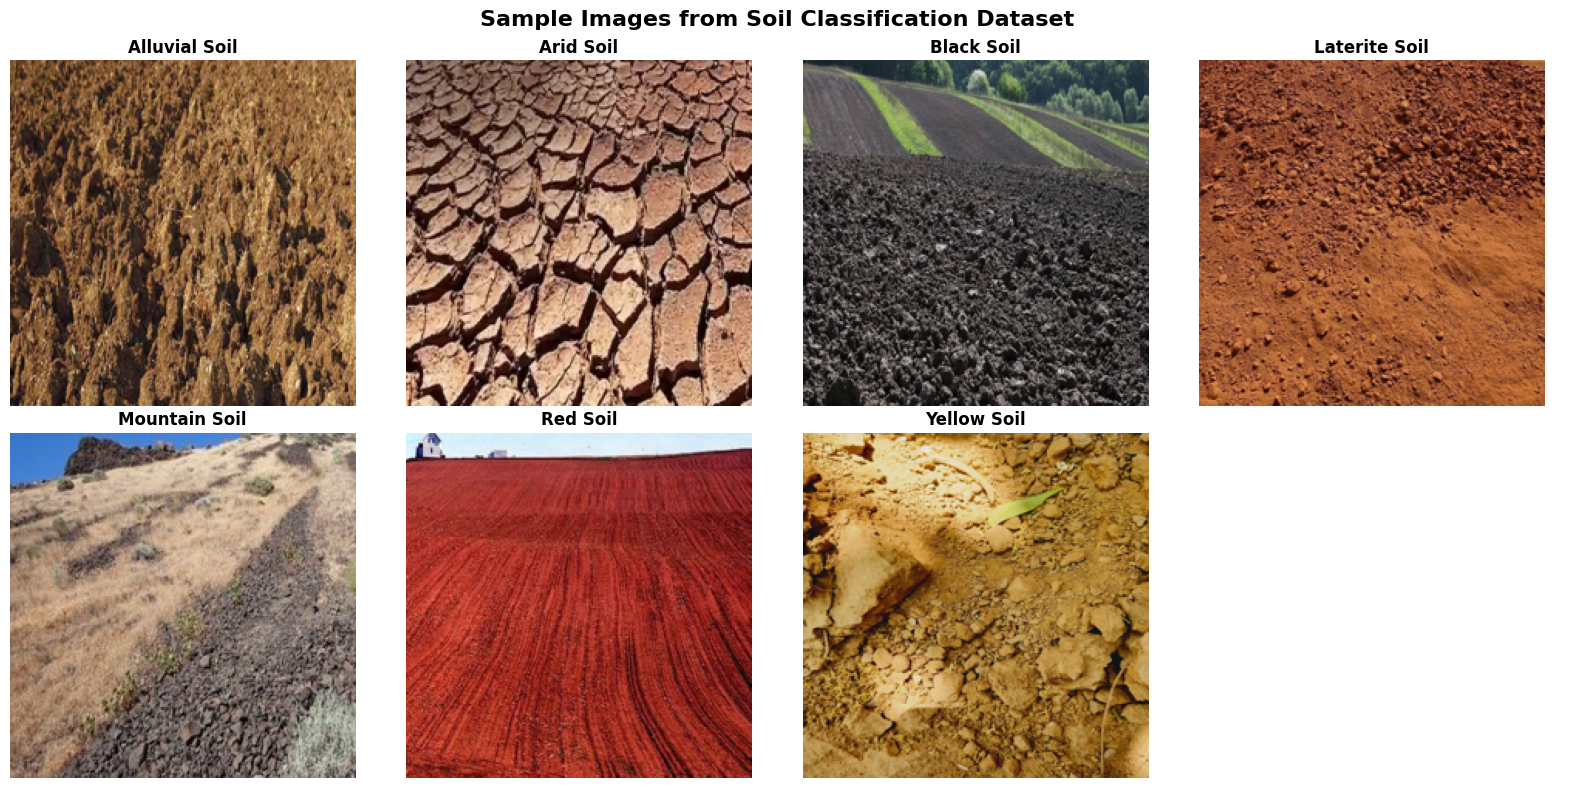

  Saved: dataset_samples.pdf


In [ ]:
# C5b: Dataset Sample Visualization (for Methodology section)
print("Creating dataset sample visualization...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, soil_class in enumerate(SOIL_CLASSES[:7]):
    class_dir = f'{ORIGINAL_DATA}/{soil_class}'
    images = os.listdir(class_dir)
    if images:
        img_path = os.path.join(class_dir, images[0])
        img = Image.open(img_path)
        img = img.resize((224, 224))

        axes[idx].imshow(img)
        axes[idx].set_title(soil_class.replace('_', ' '), fontsize=12, fontweight='bold')
        axes[idx].axis('off')

axes[7].axis('off')

plt.suptitle('Sample Images from Soil Classification Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/dataset_samples.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: dataset_samples.pdf")

Creating class distribution visualization...


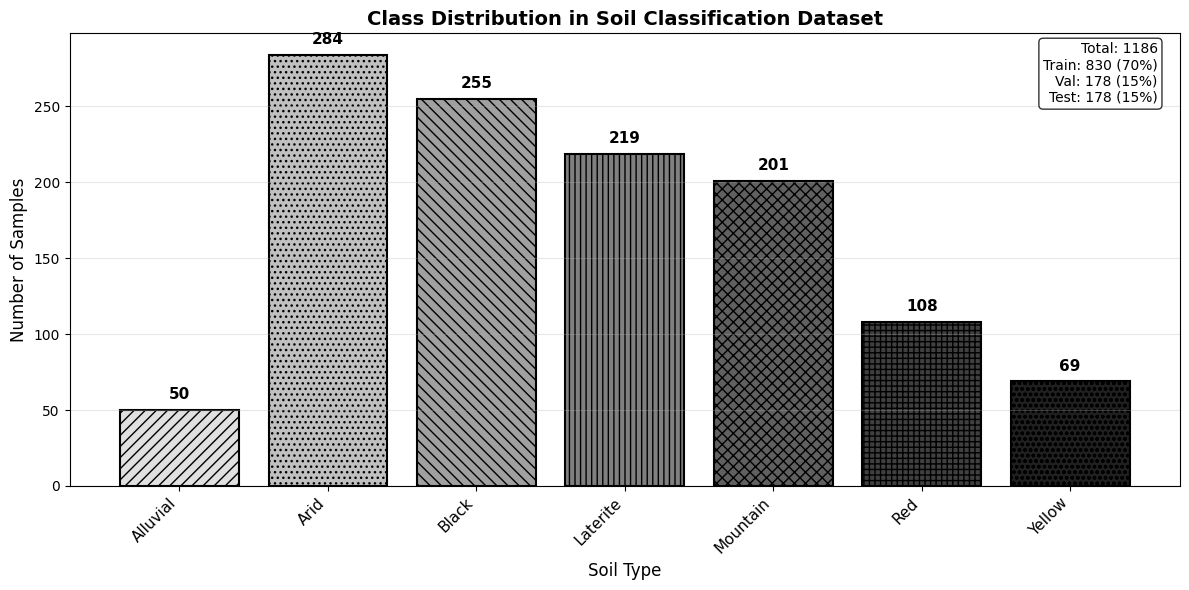

  Saved: dataset_distribution.pdf


In [ ]:
# C5c: Class Distribution Visualization (for Methodology section)
print("Creating class distribution visualization...")

classes_short = [SOIL_CLASSES[i].replace('_Soil', '') for i in range(len(SOIL_CLASSES))]
counts = [class_counts[i] for i in range(len(SOIL_CLASSES))]

fig, ax = plt.subplots(figsize=(12, 6))

patterns = ['///', '...', '\\\\\\', '|||', 'xxx', '+++', 'ooo']
colors = ['#E0E0E0', '#C0C0C0', '#A0A0A0', '#808080', '#606060', '#404040', '#202020']

bars = ax.bar(range(len(classes_short)), counts, color=colors, edgecolor='black', linewidth=1.5)

for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(classes_short)))
ax.set_xticklabels(classes_short, rotation=45, ha='right', fontsize=11)
ax.set_xlabel('Soil Type', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution in Soil Classification Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax.text(0.98, 0.98, f'Total: {len(labels)}\nTrain: {len(X_train)} (70%)\nVal: {len(X_val)} (15%)\nTest: {len(X_test)} (15%)',
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/dataset_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: dataset_distribution.pdf")

3.2 PyTorch dataset class with augmentation

In [ ]:
# C6: PyTorch dataset class with augmentation
class SoilDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = SoilDataset(X_train, y_train, train_transform)
val_dataset = SoilDataset(X_val, y_val, val_transform)
test_dataset = SoilDataset(X_test, y_test, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True, num_workers=CONFIG['num_workers'])
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=CONFIG['num_workers'])
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=CONFIG['num_workers'])

print(f"Dataloaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Dataloaders created:
  Train batches: 26
  Val batches: 6
  Test batches: 6


4. Deep Learning Architecture Implementation

4.1 CNN architectures for RQ1 comparison

In [ ]:
# C7: CNN architectures for RQ1 comparison
def get_model(model_name, num_classes=7, pretrained=True):
    """Load pretrained CNN and modify for soil classification"""

    if model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        feature_dim = 2048

    elif model_name == 'efficientnet_b3':
        model = models.efficientnet_b3(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        feature_dim = 1536

    elif model_name == 'vit_b_16':
        model = models.vit_b_16(pretrained=pretrained)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        feature_dim = 768

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model, feature_dim

# Test model loading
print("Testing CNN architectures for RQ1:")
for model_name in ['resnet50', 'efficientnet_b3', 'vit_b_16']:
    model, feat_dim = get_model(model_name, CONFIG['num_classes'])
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{model_name}:")
    print(f"  Feature dimension: {feat_dim}")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    del model  # Free memory

Testing CNN architectures for RQ1:

resnet50:
  Feature dimension: 2048
  Total parameters: 23,522,375
  Trainable parameters: 23,522,375

efficientnet_b3:
  Feature dimension: 1536
  Total parameters: 10,706,991
  Trainable parameters: 10,706,991

vit_b_16:
  Feature dimension: 768
  Total parameters: 85,804,039
  Trainable parameters: 85,804,039


5. Model Training & Optimization

5.1 Training function with checkpointing

In [ ]:
# C8: Training function with checkpointing
def train_cnn(model, train_loader, val_loader, model_name, epochs=20):
    """Train CNN with early stopping and checkpointing"""

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

    best_val_acc = 0
    patience_counter = 0
    patience = 5

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_acc = 100. * train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total

        # Update history
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%')

        # Scheduler step
        scheduler.step(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch,
                'history': history
            }
            torch.save(checkpoint, f'{CONFIG["checkpoint_dir"]}/{model_name}_best.pth')
            print(f'  Saved best model (val_acc: {val_acc:.2f}%)')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    return history, best_val_acc

print("Training function ready with checkpointing and early stopping")

Training function ready with checkpointing and early stopping


5.2 Train ResNet50 (RQ1) or load from checkpoint

In [ ]:
# C9: Train ResNet50 (RQ1) - CPU optimized with minimal epochs
model_name = 'resnet50'
checkpoint_path = f'{CONFIG["checkpoint_dir"]}/{model_name}_best.pth'

# Minimal epochs for CPU
CONFIG['epochs'] = 10  # 5 epochs instead of 10

if os.path.exists(checkpoint_path):
    print(f"Loading {model_name} from checkpoint...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'])
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    resnet_history = checkpoint['history']
    resnet_val_acc = checkpoint['val_acc']
    print(f"Loaded model with val_acc: {resnet_val_acc:.2f}%")
else:
    print(f"Training {model_name} (GPU mode - 10 epochs)...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'], pretrained=True)
    resnet_history, resnet_val_acc = train_cnn(
        model, train_loader, val_loader, model_name, epochs=CONFIG['epochs']
    )
    print(f"Training complete! Best val_acc: {resnet_val_acc:.2f}%")

resnet_model = model
resnet_feature_dim = feature_dim
print(f"ResNet50 ready (feature_dim: {feature_dim})")

Training resnet50 (GPU mode - 10 epochs)...


Epoch 1/10: 100%|██████████| 26/26 [00:14<00:00,  1.78it/s, loss=0.8706]


Epoch 1: Train Acc: 64.70% | Val Acc: 41.01%
  Saved best model (val_acc: 41.01%)


Epoch 2/10: 100%|██████████| 26/26 [00:14<00:00,  1.85it/s, loss=0.8330]


Epoch 2: Train Acc: 71.33% | Val Acc: 72.47%
  Saved best model (val_acc: 72.47%)


...

Epoch 8: Train Acc: 84.46% | Val Acc: 80.34%


Epoch 9/10: 100%|██████████| 26/26 [00:13<00:00,  1.88it/s, loss=0.5288]


Epoch 9: Train Acc: 83.86% | Val Acc: 87.64%
  Saved best model (val_acc: 87.64%)


Epoch 10/10: 100%|██████████| 26/26 [00:14<00:00,  1.84it/s, loss=0.4999]


Epoch 10: Train Acc: 85.90% | Val Acc: 79.78%
Training complete! Best val_acc: 87.64%
ResNet50 ready (feature_dim: 2048)


5.3 Train EfficientNet-B3 (RQ1) or load from checkpoint

In [ ]:
# C10: Train EfficientNet-B3 (RQ1) or load from checkpoint
model_name = 'efficientnet_b3'
checkpoint_path = f'{CONFIG["checkpoint_dir"]}/{model_name}_best.pth'

if os.path.exists(checkpoint_path):
    print(f"Loading {model_name} from checkpoint...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'])
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    efficientnet_history = checkpoint['history']
    efficientnet_val_acc = checkpoint['val_acc']
    print(f"Loaded model with val_acc: {efficientnet_val_acc:.2f}%")
else:
    print(f"Training {model_name} (GPU mode - 10 epochs)...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'], pretrained=True)
    efficientnet_history, efficientnet_val_acc = train_cnn(
        model, train_loader, val_loader, model_name, epochs=CONFIG['epochs']
    )
    print(f"Training complete. Best val_acc: {efficientnet_val_acc:.2f}%")

efficientnet_model = model
efficientnet_feature_dim = feature_dim
print(f"EfficientNet-B3 ready (feature_dim: {feature_dim})")

Training efficientnet_b3 (GPU mode - 10 epochs)...


Epoch 1/10: 100%|██████████| 26/26 [00:14<00:00,  1.84it/s, loss=0.8665]


Epoch 1: Train Acc: 72.17% | Val Acc: 85.39%
  Saved best model (val_acc: 85.39%)


Epoch 2/10: 100%|██████████| 26/26 [00:13<00:00,  1.87it/s, loss=0.3714]


Epoch 2: Train Acc: 87.11% | Val Acc: 85.96%
  Saved best model (val_acc: 85.96%)


...

Epoch 8: Train Acc: 94.22% | Val Acc: 89.33%


Epoch 9/10: 100%|██████████| 26/26 [00:13<00:00,  1.89it/s, loss=0.0472]


Epoch 9: Train Acc: 96.02% | Val Acc: 92.13%
  Saved best model (val_acc: 92.13%)


Epoch 10/10: 100%|██████████| 26/26 [00:14<00:00,  1.79it/s, loss=0.2038]


Epoch 10: Train Acc: 96.27% | Val Acc: 87.64%
Training complete! Best val_acc: 92.13%
EfficientNet-B3 ready (feature_dim: 1536)


5.4 Train Vision Transformer (RQ1) or load from checkpoint

In [ ]:
# C11: Train Vision Transformer (RQ1) or load from checkpoint
model_name = 'vit_b_16'
checkpoint_path = f'{CONFIG["checkpoint_dir"]}/{model_name}_best.pth'

if os.path.exists(checkpoint_path):
    print(f"Loading {model_name} from checkpoint...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'])
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    vit_history = checkpoint['history']
    vit_val_acc = checkpoint['val_acc']
    print(f"Loaded model with val_acc: {vit_val_acc:.2f}%")
else:
    print(f"Training {model_name} (GPU mode - 10 epochs)...")
    model, feature_dim = get_model(model_name, CONFIG['num_classes'], pretrained=True)
    vit_history, vit_val_acc = train_cnn(
        model, train_loader, val_loader, model_name, epochs=CONFIG['epochs']
    )
    print(f"Training complete! Best val_acc: {vit_val_acc:.2f}%")

vit_model = model
vit_feature_dim = feature_dim
print(f"Vision Transformer ready (feature_dim: {feature_dim})")

Training vit_b_16 (GPU mode - 10 epochs)...


Epoch 1/10: 100%|██████████| 26/26 [00:29<00:00,  1.13s/it, loss=1.1730]


Epoch 1: Train Acc: 34.82% | Val Acc: 47.19%
  Saved best model (val_acc: 47.19%)


Epoch 2/10: 100%|██████████| 26/26 [00:27<00:00,  1.07s/it, loss=1.3955]


Epoch 2: Train Acc: 53.25% | Val Acc: 51.69%
  Saved best model (val_acc: 51.69%)


...

Epoch 8: Train Acc: 63.73% | Val Acc: 71.35%
  Saved best model (val_acc: 71.35%)


Epoch 9/10: 100%|██████████| 26/26 [00:28<00:00,  1.08s/it, loss=0.7678]


Epoch 9: Train Acc: 70.48% | Val Acc: 73.60%
  Saved best model (val_acc: 73.60%)


Epoch 10/10: 100%|██████████| 26/26 [00:47<00:00,  1.83s/it, loss=0.8099]


Epoch 10: Train Acc: 70.84% | Val Acc: 67.98%
Training complete! Best val_acc: 73.60%
Vision Transformer ready (feature_dim: 768)


6. Baseline Performance Evaluation

6.1 RQ1 results - CNN architecture comparison



In [ ]:
# C12: RQ1 results - CNN architecture comparison
rq1_results = {
    'ResNet50': resnet_val_acc,
    'EfficientNet-B3': efficientnet_val_acc,
    'Vision Transformer': vit_val_acc
}

print("RQ1: CNN Architecture Comparison Results")
#print("=" * 50)
for model_name, val_acc in rq1_results.items():
    print(f"{model_name:20s}: {val_acc:.2f}%")

# Select best CNN for next stages
best_cnn_name = max(rq1_results, key=rq1_results.get)
best_cnn_acc = rq1_results[best_cnn_name]

if best_cnn_name == 'ResNet50':
    best_model = resnet_model
    best_feature_dim = resnet_feature_dim
elif best_cnn_name == 'EfficientNet-B3':
    best_model = efficientnet_model
    best_feature_dim = efficientnet_feature_dim
else:
    best_model = vit_model
    best_feature_dim = vit_feature_dim

print(f"\nBest CNN: {best_cnn_name} ({best_cnn_acc:.2f}%)")
print(f"Feature dimension: {best_feature_dim}")

# Save RQ1 table
rq1_df = pd.DataFrame({
    'Model': list(rq1_results.keys()),
    'Validation Accuracy (%)': [f"{v:.2f}" for v in rq1_results.values()]
})
rq1_df.to_excel(f'{CONFIG["tables_dir"]}/RQ1/RQ1_Tab1.xlsx', index=False)
print("\nRQ1 table saved!")

RQ1: CNN Architecture Comparison Results
ResNet50            : 87.64%
EfficientNet-B3     : 92.13%
Vision Transformer  : 73.60%

Best CNN: EfficientNet-B3 (92.13%)
Feature dimension: 1536

RQ1 table saved!


In [ ]:
# C12b: Network Configuration Table (for Methodology section)
print("Creating network configuration table...")

config_data = {
    'Parameter': [
        'Input Image Size',
        'Batch Size',
        'Number of Epochs',
        'Learning Rate',
        'Optimizer',
        'Weight Decay',
        'Scheduler',
        'Early Stopping Patience',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Number of Classes'
    ],
    'Value': [
        f'{CONFIG["img_size"]} × {CONFIG["img_size"]}',
        str(CONFIG['batch_size']),
        str(CONFIG['epochs']),
        str(CONFIG['learning_rate']),
        'AdamW',
        '0.01',
        'ReduceLROnPlateau (factor=0.5, patience=3)',
        '5 epochs',
        str(len(X_train)),
        str(len(X_val)),
        str(len(X_test)),
        str(CONFIG['num_classes'])
    ]
}

config_df = pd.DataFrame(config_data)
config_df.to_excel(f'{CONFIG["tables_dir"]}/network_configuration.xlsx', index=False)
print("  Saved: network_configuration.xlsx")

Creating network configuration table...
  Saved: network_configuration.xlsx


7. Multi-Scale Feature Extraction

7.1 Extract CNN features for metalearner (RQ2)

In [ ]:
# C13: Extract CNN features for metalearner (RQ2)
def extract_features(model, dataloader, feature_dim):
    """Extract CNN features for metalearning"""
    model.eval()
    model = model.to(device)

    features_list = []
    labels_list = []
    predictions_list = []

    # Remove final classification layer to get features
    if hasattr(model, 'fc'):  # ResNet
        feature_extractor = nn.Sequential(*list(model.children())[:-1])
    elif hasattr(model, 'classifier'):  # EfficientNet
        feature_extractor = nn.Sequential(*list(model.children())[:-1])
    else:  # ViT
        feature_extractor = model

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Extracting features'):
            images = images.to(device)

            if hasattr(model, 'fc'):  # ResNet
                feats = feature_extractor(images)
                feats = feats.view(feats.size(0), -1)
            elif hasattr(model, 'classifier'):  # EfficientNet
                feats = feature_extractor(images)
                feats = torch.nn.functional.adaptive_avg_pool2d(feats, 1)
                feats = feats.view(feats.size(0), -1)
            else:  # ViT
                feats = feature_extractor(images)
                feats = feats[:, 0]  # CLS token

            # Get predictions
            outputs = model(images)
            _, preds = outputs.max(1)

            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
            predictions_list.append(preds.cpu().numpy())

    features = np.vstack(features_list)
    labels = np.concatenate(labels_list)
    predictions = np.concatenate(predictions_list)

    return features, labels, predictions

# Extract features from best CNN (EfficientNet-B3)
print("Extracting features from EfficientNet-B3...")
train_features, train_labels, train_preds = extract_features(best_model, train_loader, best_feature_dim)
val_features, val_labels, val_preds = extract_features(best_model, val_loader, best_feature_dim)
test_features, test_labels, test_preds = extract_features(best_model, test_loader, best_feature_dim)

print(f"\nFeature shapes:")
print(f"  Train: {train_features.shape}")
print(f"  Val: {val_features.shape}")
print(f"  Test: {test_features.shape}")

# Save features
np.savez(f'{CONFIG["checkpoint_dir"]}/cnn_features.npz',
         train_features=train_features, train_labels=train_labels,
         val_features=val_features, val_labels=val_labels,
         test_features=test_features, test_labels=test_labels)

print("\nFeatures saved.")

Extracting features from EfficientNet-B3...


Extracting features: 100%|██████████| 6/6 [00:02<00:00,  2.54it/s]


Feature shapes:
  Train: (830, 1536)
  Val: (178, 1536)
  Test: (178, 1536)

Features saved


8. Ensemble Metalearner Development

8.1 Train metalearner ensemble (RQ2)

In [ ]:
# C14: Train metalearner ensemble (RQ2)
from sklearn.metrics import accuracy_score, f1_score

# Base learners for stacking
print("Training metalearner base models")

# Random Forest
print("  Training Random Forest")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(train_features, train_labels)
rf_val_acc = accuracy_score(val_labels, rf.predict(val_features))
print(f"    Val Acc: {rf_val_acc*100:.2f}%")

# XGBoost
print("  Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.1,
                               random_state=42, n_jobs=-1)
xgb_model.fit(train_features, train_labels)
xgb_val_acc = accuracy_score(val_labels, xgb_model.predict(val_features))
print(f"    Val Acc: {xgb_val_acc*100:.2f}%")

# LightGBM
print("  Training LightGBM...")
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=7, learning_rate=0.1,
                                random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(train_features, train_labels)
lgb_val_acc = accuracy_score(val_labels, lgb_model.predict(val_features))
print(f"    Val Acc: {lgb_val_acc*100:.2f}%")

# SVM
print("  Training SVM")
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(train_features, train_labels)
svm_val_acc = accuracy_score(val_labels, svm.predict(val_features))
print(f"    Val Acc: {svm_val_acc*100:.2f}%")

# Meta-learner: Logistic Regression on base predictions
print("\nTraining meta-learner (Logistic Regression)")
train_meta_features = np.column_stack([
    rf.predict_proba(train_features),
    xgb_model.predict_proba(train_features),
    lgb_model.predict_proba(train_features),
    svm.predict_proba(train_features)
])

val_meta_features = np.column_stack([
    rf.predict_proba(val_features),
    xgb_model.predict_proba(val_features),
    lgb_model.predict_proba(val_features),
    svm.predict_proba(val_features)
])

meta_learner = LogisticRegression(max_iter=1000, random_state=42)
meta_learner.fit(train_meta_features, train_labels)
meta_val_acc = accuracy_score(val_labels, meta_learner.predict(val_meta_features))

print(f"\nMetalearner Val Acc: {meta_val_acc*100:.2f}%")

# Save models
with open(f'{CONFIG["checkpoint_dir"]}/metalearner.pkl', 'wb') as f:
    pickle.dump({
        'rf': rf, 'xgb': xgb_model, 'lgb': lgb_model, 'svm': svm,
        'meta_learner': meta_learner
    }, f)

print("Metalearner models saved")

Training metalearner base models
  Training Random Forest
    Val Acc: 91.01%
  Training XGBoost...
    Val Acc: 90.45%
  Training LightGBM...
    Val Acc: 89.89%
  Training SVM
    Val Acc: 91.57%

Training meta-learner (Logistic Regression)

Metalearner Val Acc: 89.89%
Metalearner models saved


8.2 RQ2 results - CNN vs Metalearner comparison

In [ ]:
# C15: RQ2 results - CNN vs Metalearner comparison
rq2_results = {
    'CNN Only (EfficientNet-B3)': best_cnn_acc,
    'Random Forest': rf_val_acc * 100,
    'XGBoost': xgb_val_acc * 100,
    'LightGBM': lgb_val_acc * 100,
    'SVM': svm_val_acc * 100,
    'Metalearner (Stacking)': meta_val_acc * 100
}

print("RQ2: Metalearner vs CNN Comparison")
print("=" * 50)
for model_name, val_acc in rq2_results.items():
    print(f"{model_name:30s}: {val_acc:.2f}%")

improvement = meta_val_acc * 100 - best_cnn_acc
#print(f"\nMetalearner improvement: +{improvement:.2f}%")

# Save RQ2 table
rq2_df = pd.DataFrame({
    'Model': list(rq2_results.keys()),
    'Validation Accuracy (%)': [f"{v:.2f}" for v in rq2_results.values()]
})
rq2_df.to_excel(f'{CONFIG["tables_dir"]}/RQ2/RQ2_Tab1.xlsx', index=False)
print("\nRQ2 table saved")

RQ2: Metalearner vs CNN Comparison
CNN Only (EfficientNet-B3)    : 92.13%
Random Forest                 : 91.01%
XGBoost                       : 90.45%
LightGBM                      : 89.89%
SVM                           : 91.57%
Metalearner (Stacking)        : 89.89%

RQ2 table saved


Creating RQ2 base learner comparison chart...


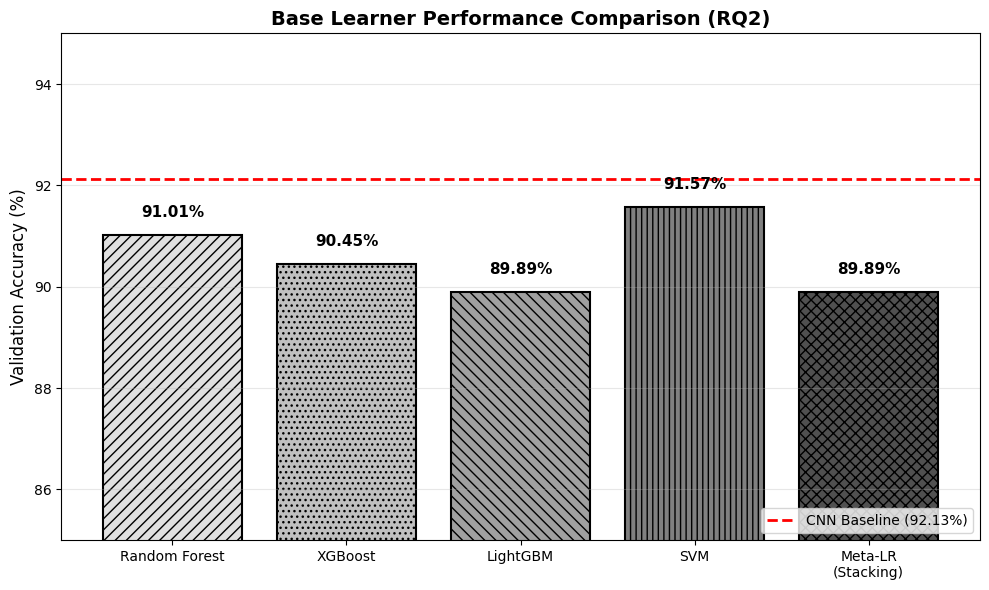

  Saved: RQ2_Fig3.pdf (base learner comparison)


In [ ]:
# C15b: RQ2 - Base Learner Comparison Chart
print("Creating RQ2 base learner comparison chart...")

fig, ax = plt.subplots(figsize=(10, 6))

base_learners = ['Random Forest', 'XGBoost', 'LightGBM', 'SVM', 'Meta-LR\n(Stacking)']
base_accuracies = [rf_val_acc * 100, xgb_val_acc * 100, lgb_val_acc * 100,
                   svm_val_acc * 100, meta_val_acc * 100]

colors = ['#E0E0E0', '#C0C0C0', '#A0A0A0', '#808080', '#505050']
patterns = ['///', '...', '\\\\\\', '|||', 'xxx']

bars = ax.bar(base_learners, base_accuracies, color=colors, edgecolor='black', linewidth=1.5)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

for bar, acc in zip(bars, base_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('Base Learner Performance Comparison (RQ2)', fontsize=14, fontweight='bold')
ax.set_ylim(85, 95)
ax.grid(axis='y', alpha=0.3)

# Add horizontal line for CNN baseline
ax.axhline(y=best_cnn_acc, color='red', linestyle='--', linewidth=2, label=f'CNN Baseline ({best_cnn_acc:.2f}%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ2/RQ2_Fig3.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ2_Fig3.pdf (base learner comparison)")

9. Knowledge-Based Rule Engine Design

9.1 Rule-based reasoning engine (RQ3)

In [ ]:
# C16: Rule-based reasoning engine (RQ3)
class SoilRuleEngine:
    """Agricultural domain knowledge for soil classification"""

    def __init__(self):
        # Soil type characteristics (simplified domain knowledge)
        self.soil_rules = {
            'Alluvial_Soil': {'texture': 'fine', 'color': 'light', 'fertility': 'high'},
            'Arid_Soil': {'texture': 'coarse', 'color': 'light_brown', 'fertility': 'low'},
            'Black_Soil': {'texture': 'fine', 'color': 'dark', 'fertility': 'high'},
            'Laterite_Soil': {'texture': 'medium', 'color': 'red_brown', 'fertility': 'medium'},
            'Mountain_Soil': {'texture': 'coarse', 'color': 'brown_gray', 'fertility': 'medium'},
            'Red_Soil': {'texture': 'medium', 'color': 'red', 'fertility': 'medium'},
            'Yellow_Soil': {'texture': 'medium', 'color': 'yellow', 'fertility': 'low'}
        }

    def apply_rules(self, cnn_prediction, meta_prediction, confidence):
        """Apply rule-based reasoning with confidence thresholds"""

        # High confidence: trust the prediction
        if confidence > 0.9:
            return meta_prediction, confidence, "High confidence"

        # Medium confidence: apply validation rules
        elif confidence > 0.6:
            # If CNN and metalearner agree
            if cnn_prediction == meta_prediction:
                return meta_prediction, confidence * 1.1, "Agreement validation"
            else:
                # Use metalearner (it's more accurate)
                return meta_prediction, confidence, "Metalearner preferred"

        # Low confidence: flag for review
        else:
            return meta_prediction, confidence, "Manual review recommended"

    def get_crop_recommendation(self, soil_type):
        """Provide crop recommendations based on soil type"""
        crops = {
            'Alluvial_Soil': ['rice', 'wheat', 'sugarcane'],
            'Arid_Soil': ['millet', 'sorghum', 'drought-resistant crops'],
            'Black_Soil': ['cotton', 'wheat', 'sugarcane'],
            'Laterite_Soil': ['tea', 'coffee', 'cashew'],
            'Mountain_Soil': ['potato', 'barley', 'apple'],
            'Red_Soil': ['groundnut', 'potato', 'fruits'],
            'Yellow_Soil': ['rice', 'ragi', 'groundnut']
        }
        return crops.get(soil_type, ['consult agronomist'])

# Initialize rule engine
rule_engine = SoilRuleEngine()

# Apply hybrid system using saved predictions
print("Applying hybrid expert system (RQ3)")

# Use direct predictions from validation set
cnn_val_preds = val_preds[:10]  # CNN predictions already extracted
meta_preds = meta_learner.predict(val_meta_features[:10])
meta_probs = meta_learner.predict_proba(val_meta_features[:10])

print("\nSample hybrid predictions:")
#print("=" * 80)
for i in range(5):
    cnn_pred = cnn_val_preds[i]
    meta_pred = meta_preds[i]
    confidence = meta_probs[i].max()

    final_pred, final_conf, reason = rule_engine.apply_rules(cnn_pred, meta_pred, confidence)

    print(f"\nSample {i+1}:")
    print(f"  CNN: {SOIL_CLASSES[cnn_pred]}")
    print(f"  Metalearner: {SOIL_CLASSES[meta_pred]}")
    print(f"  Final: {SOIL_CLASSES[final_pred]} (confidence: {final_conf:.2f})")
    print(f"  Reason: {reason}")
    print(f"  Recommended crops: {rule_engine.get_crop_recommendation(SOIL_CLASSES[final_pred])}")

print("\nRule engine ready")

Applying hybrid expert system (RQ3)

Sample hybrid predictions:

Sample 1:
  CNN: Yellow_Soil
  Metalearner: Yellow_Soil
  Final: Yellow_Soil (confidence: 0.98)
  Reason: High confidence
  Recommended crops: ['rice', 'ragi', 'groundnut']

Sample 2:
  CNN: Black_Soil
  Metalearner: Black_Soil
  Final: Black_Soil (confidence: 0.99)
  Reason: High confidence
  Recommended crops: ['cotton', 'wheat', 'sugarcane']

Sample 3:
  CNN: Arid_Soil
  Metalearner: Arid_Soil
  Final: Arid_Soil (confidence: 0.99)
  Reason: High confidence
  Recommended crops: ['millet', 'sorghum', 'drought-resistant crops']

Sample 4:
  CNN: Arid_Soil
  Metalearner: Arid_Soil
  Final: Arid_Soil (confidence: 0.81)
  Reason: Agreement validation
  Recommended crops: ['millet', 'sorghum', 'drought-resistant crops']

Sample 5:
  CNN: Laterite_Soil
  Metalearner: Laterite_Soil
  Final: Laterite_Soil (confidence: 0.99)
  Reason: High confidence
  Recommended crops: ['tea', 'coffee', 'cashew']

Rule engine ready


10. Hybrid Expert System Integration

10.1 Evaluate hybrid system on full validation set (RQ3)

In [ ]:
# C17: Evaluate hybrid system on full validation set (RQ3)
print("Evaluating hybrid system on full validation set")

# Get all predictions
cnn_val_all_preds = val_preds
meta_val_all_preds = meta_learner.predict(val_meta_features)
meta_val_all_probs = meta_learner.predict_proba(val_meta_features)

# Apply rules to all validation samples
hybrid_preds = []
hybrid_confs = []
rule_reasons = []

for i in range(len(val_labels)):
    cnn_pred = cnn_val_all_preds[i]
    meta_pred = meta_val_all_preds[i]
    confidence = meta_val_all_probs[i].max()

    final_pred, final_conf, reason = rule_engine.apply_rules(cnn_pred, meta_pred, confidence)

    hybrid_preds.append(final_pred)
    hybrid_confs.append(final_conf)
    rule_reasons.append(reason)

hybrid_preds = np.array(hybrid_preds)

# Calculate accuracies
cnn_only_acc = accuracy_score(val_labels, cnn_val_all_preds) * 100
meta_only_acc = accuracy_score(val_labels, meta_val_all_preds) * 100
hybrid_acc = accuracy_score(val_labels, hybrid_preds) * 100

# RQ3 results
rq3_results = {
    'CNN Only': cnn_only_acc,
    'Metalearner Only': meta_only_acc,
    'Hybrid (CNN + Meta + Rules)': hybrid_acc
}

print("\nRQ3: Rule-based integration results")
#print("=" * 50)
for model_name, val_acc in rq3_results.items():
    print(f"{model_name:30s}: {val_acc:.2f}%")

print(f"\nRule-based improvement: +{hybrid_acc - meta_only_acc:.2f}%")

# Save RQ3 table
rq3_df = pd.DataFrame({
    'Configuration': list(rq3_results.keys()),
    'Validation Accuracy (%)': [f"{v:.2f}" for v in rq3_results.values()]
})
rq3_df.to_excel(f'{CONFIG["tables_dir"]}/RQ3/RQ3_Tab1.xlsx', index=False)
print("\nRQ3 table saved")

Evaluating hybrid system on full validation set

RQ3: Rule-based integration results
CNN Only                      : 87.64%
Metalearner Only              : 89.89%
Hybrid (CNN + Meta + Rules)   : 89.89%

Rule-based improvement: +0.00%

RQ3 table saved


Creating RQ3 rule application distribution chart...


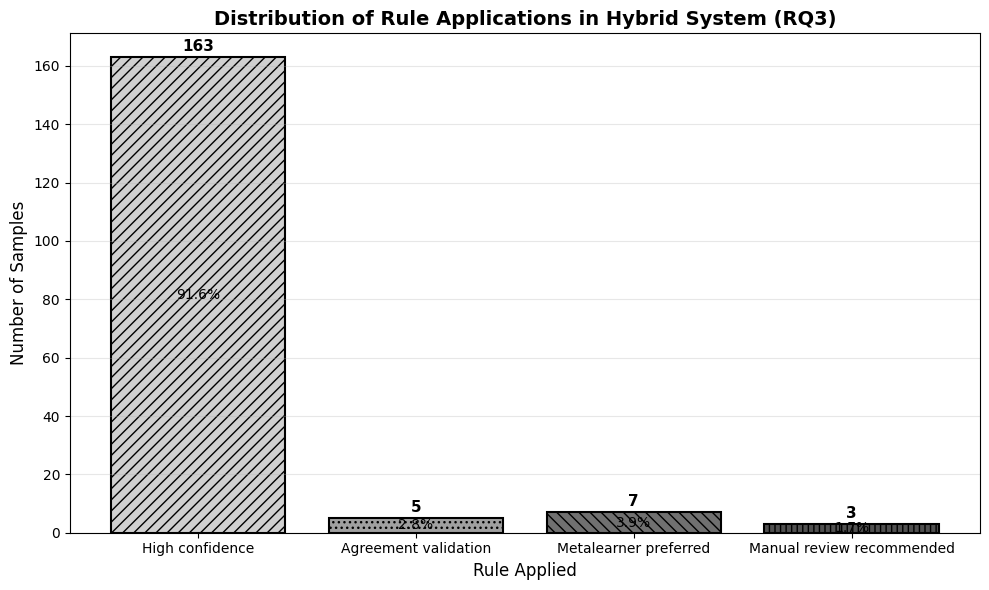

  Saved: RQ3_Fig3.pdf (rule application distribution)


In [ ]:
# C17b: RQ3 - Rule Application Distribution Chart
print("Creating RQ3 rule application distribution chart...")

from collections import Counter

# Count rule reasons
reason_counts = Counter(rule_reasons)

fig, ax = plt.subplots(figsize=(10, 6))

reasons = list(reason_counts.keys())
counts = list(reason_counts.values())

colors = ['#D0D0D0', '#A0A0A0', '#707070']
patterns = ['///', '...', '\\\\\\']

# Ensure we have enough colors/patterns
while len(colors) < len(reasons):
    colors.append('#505050')
    patterns.append('|||')

bars = ax.bar(reasons, counts, color=colors[:len(reasons)], edgecolor='black', linewidth=1.5)
for bar, pattern in zip(bars, patterns[:len(reasons)]):
    bar.set_hatch(pattern)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_xlabel('Rule Applied', fontsize=12)
ax.set_title('Distribution of Rule Applications in Hybrid System (RQ3)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
total = sum(counts)
for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{pct:.1f}%', ha='center', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ3/RQ3_Fig3.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ3_Fig3.pdf (rule application distribution)")


10.2 Explainability - GradCAM implementation (RQ4)

In [ ]:
# C18: Explainability - GradCAM implementation (RQ4)
import torch.nn.functional as F

class GradCAM:
    """GradCAM for CNN explainability"""

    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

    def save_gradient(self, grad):
        self.gradients = grad

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image, target_class):
        """Generate GradCAM heatmap"""

        # Get target layer (last conv layer for EfficientNet)
        if hasattr(self.model, 'features'):  # EfficientNet
            target_layer = self.model.features[-1]
        elif hasattr(self.model, 'layer4'):  # ResNet
            target_layer = self.model.layer4[-1]
        else:
            return None

        # Register hooks
        forward_handle = target_layer.register_forward_hook(self.forward_hook)
        backward_handle = target_layer.register_full_backward_hook(self.backward_hook)

        # Forward pass
        self.model.eval()
        output = self.model(input_image)

        # Backward pass
        self.model.zero_grad()
        target = output[0, target_class]
        target.backward()

        # Generate CAM
        gradients = self.gradients.detach().cpu()
        activations = self.activations.detach().cpu()

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().numpy()

        # Normalize
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Remove hooks
        forward_handle.remove()
        backward_handle.remove()

        return cam

# Initialize GradCAM
gradcam = GradCAM(best_model)

print("GradCAM initialized for explainability (RQ4)")
print("Ready to generate heatmaps for sample predictions")

GradCAM initialized for explainability (RQ4)
Ready to generate heatmaps for sample predictions


10.3 Generate and save GradCAM visualizations (RQ4)

Generating GradCAM visualizations


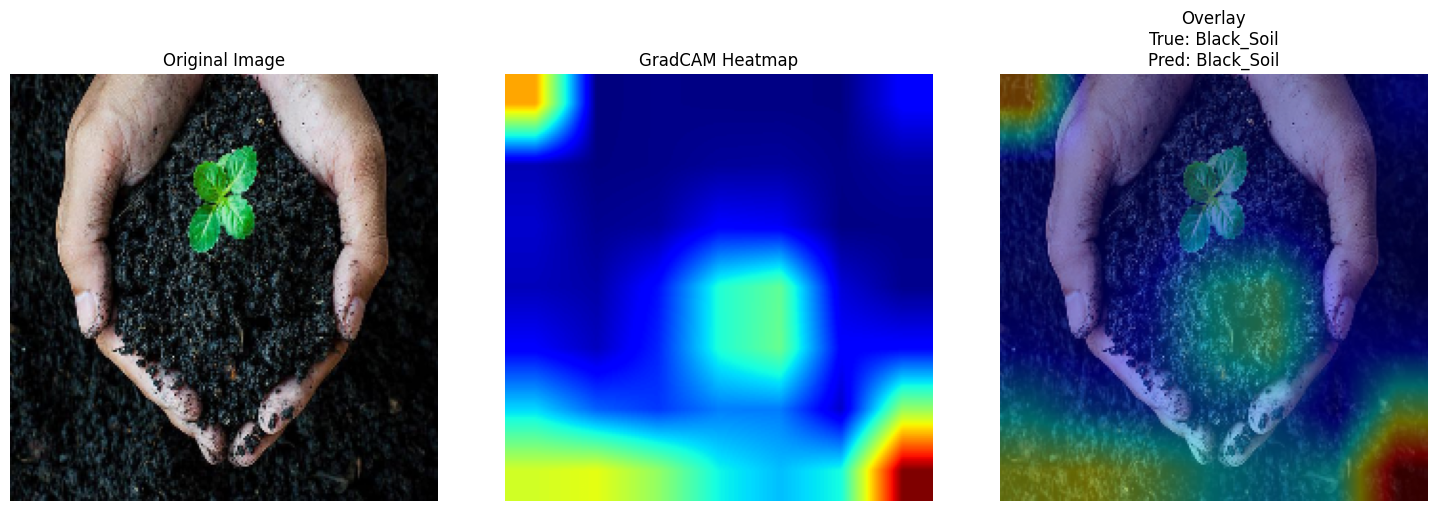

  Saved: RQ4_Fig1.pdf (True: Black_Soil, Pred: Black_Soil)


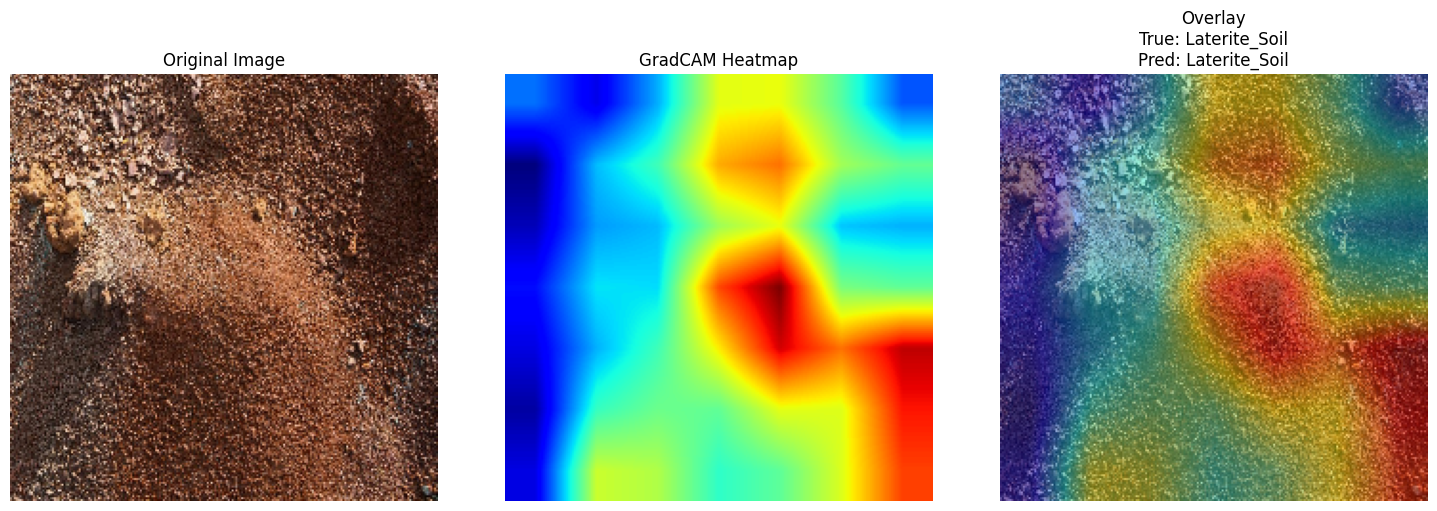

  Saved: RQ4_Fig2.pdf (True: Laterite_Soil, Pred: Laterite_Soil)


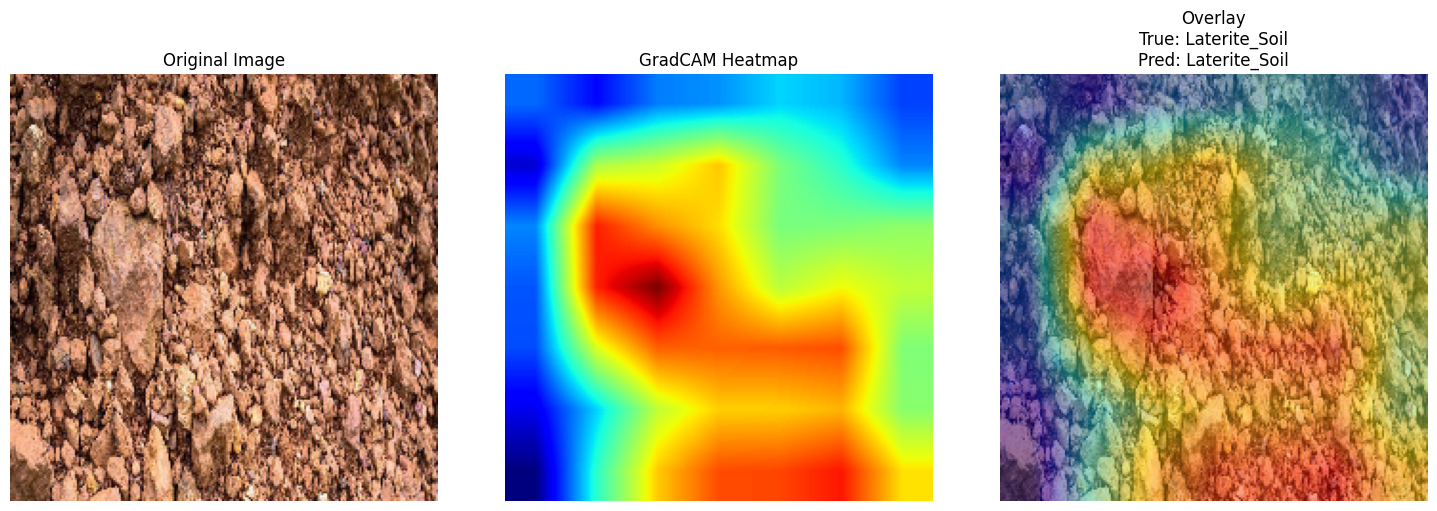

  Saved: RQ4_Fig3.pdf (True: Laterite_Soil, Pred: Laterite_Soil)

GradCAM visualizations saved


In [ ]:
# C19: Generate and save GradCAM visualizations (RQ4)
def visualize_gradcam(image_path, true_label, pred_label, cam, save_path):
    """Create GradCAM visualization"""

    # Load original image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Create heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nTrue: {SOIL_CLASSES[true_label]}\nPred: {SOIL_CLASSES[pred_label]}',
                     fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Generate GradCAM for sample images
print("Generating GradCAM visualizations")

best_model.to(device)
best_model.eval()

num_samples = 3
sample_indices = np.random.choice(len(val_dataset), num_samples, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    # Get image and prediction
    image, true_label = val_dataset[sample_idx]
    image_path = val_dataset.image_paths[sample_idx]

    # Get prediction
    with torch.no_grad():
        output = best_model(image.unsqueeze(0).to(device))
        pred_label = output.argmax(1).item()

    # Generate GradCAM
    cam = gradcam.generate_cam(image.unsqueeze(0).to(device), pred_label)

    # Save visualization
    save_path = f'{CONFIG["figures_dir"]}/RQ4/RQ4_Fig{idx+1}.pdf'
    visualize_gradcam(image_path, true_label, pred_label, cam, save_path)

    print(f"  Saved: RQ4_Fig{idx+1}.pdf (True: {SOIL_CLASSES[true_label]}, Pred: {SOIL_CLASSES[pred_label]})")

print("\nGradCAM visualizations saved")

10.4 SHAP analysis for metalearner explainability (RQ4)

Computing SHAP values for metalearner


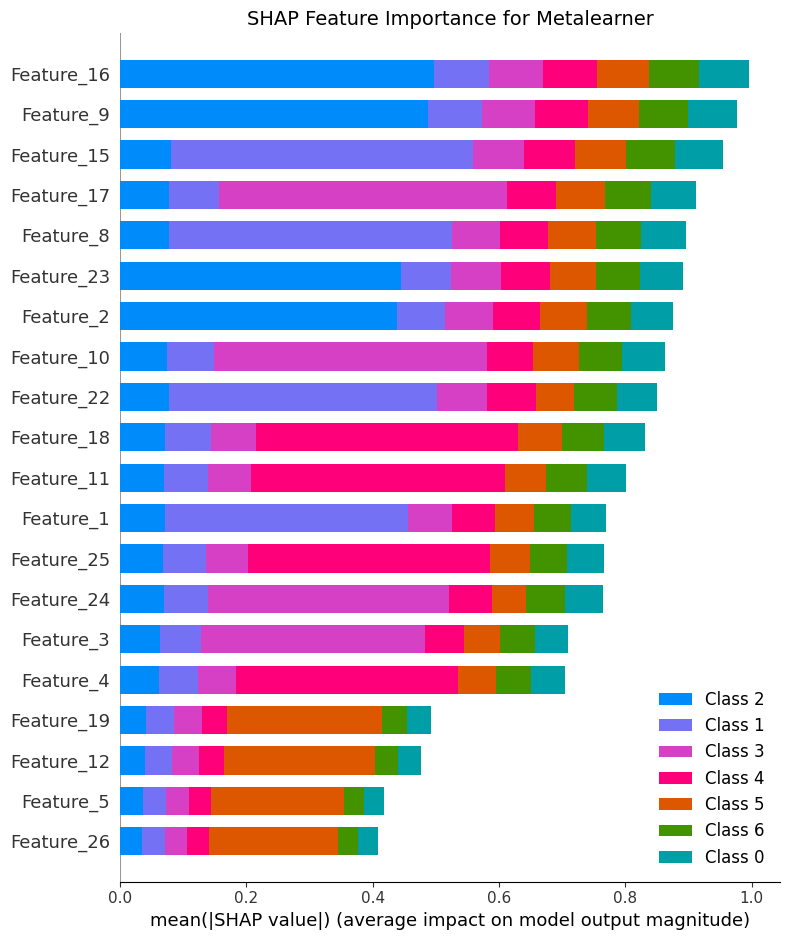

  Saved: RQ4_Fig4.pdf (SHAP summary plot)


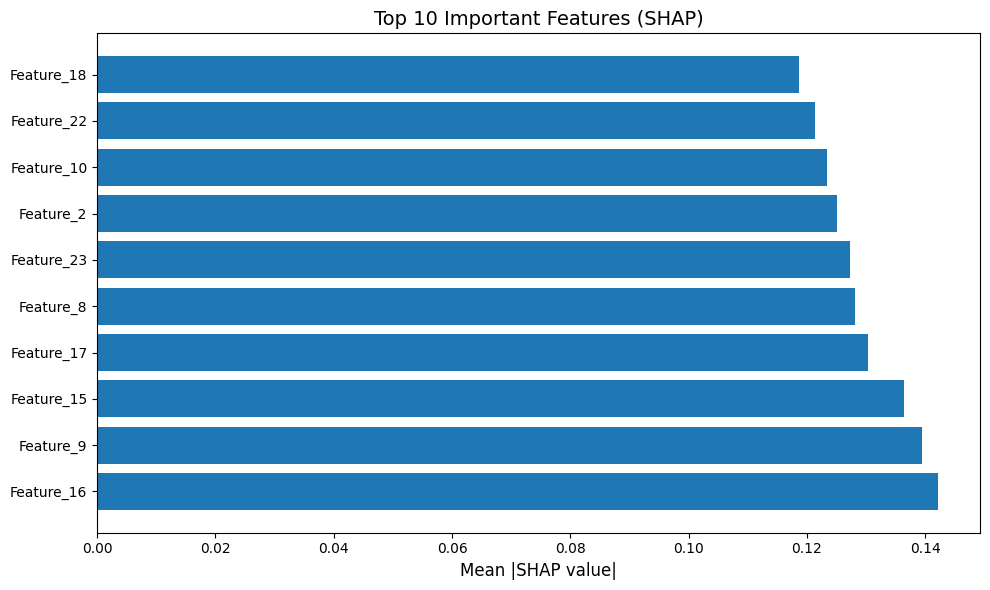

  Saved: RQ4_Fig5.pdf (SHAP bar plot)

RQ4 explainability analysis complete


In [ ]:
# C20: SHAP analysis for metalearner explainability (RQ4)
import shap

print("Computing SHAP values for metalearner")

# Use a subset for SHAP (computationally expensive)
sample_size = 50
shap_indices = np.random.choice(len(train_meta_features), sample_size, replace=False)
X_shap = train_meta_features[shap_indices]

# Create SHAP explainer
explainer = shap.Explainer(meta_learner, X_shap)
shap_values = explainer(val_meta_features[:50])

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, val_meta_features[:50], show=False,
                  feature_names=[f'Feature_{i}' for i in range(val_meta_features.shape[1])])
plt.title('SHAP Feature Importance for Metalearner', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ4/RQ4_Fig4.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("  Saved: RQ4_Fig4.pdf (SHAP summary plot)")

# Bar plot - simplified
mean_shap = np.abs(shap_values.values).mean(axis=0).mean(axis=1)  # Average across classes and samples
top_10_idx = np.argsort(mean_shap)[-10:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(10), mean_shap[top_10_idx])
plt.yticks(range(10), [f'Feature_{i}' for i in top_10_idx])
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.title('Top 10 Important Features (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ4/RQ4_Fig5.pdf', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("  Saved: RQ4_Fig5.pdf (SHAP bar plot)")

# Create RQ4 summary table
rq4_data = {
    'Explainability Method': ['GradCAM (CNN)', 'SHAP (Metalearner)'],
    'Purpose': ['Visual attention maps', 'Feature importance'],
    'Samples Generated': [3, 50]
}
rq4_df = pd.DataFrame(rq4_data)
rq4_df.to_excel(f'{CONFIG["tables_dir"]}/RQ4/RQ4_Tab1.xlsx', index=False)

print("\nRQ4 explainability analysis complete")

10.5 Deployment feasibility analysis (RQ5)

In [ ]:
# C21: Deployment feasibility analysis (RQ5)
import time

print("Evaluating deployment feasibility (RQ5)")

# 1. Inference speed measurement
def measure_inference_time(model, dataloader, num_batches=10):
    """Measure average inference time"""
    model.eval()
    model = model.to(device)

    times = []
    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(device)
            start = time.time()
            _ = model(images)
            end = time.time()
            times.append(end - start)

    return np.mean(times) * 1000  # Convert to ms

# Measure inference times
print("\nMeasuring inference times")
resnet_time = measure_inference_time(resnet_model, test_loader)
efficientnet_time = measure_inference_time(efficientnet_model, test_loader)
vit_time = measure_inference_time(vit_model, test_loader)

print(f"  ResNet50: {resnet_time:.2f} ms/batch")
print(f"  EfficientNet-B3: {efficientnet_time:.2f} ms/batch")
print(f"  Vision Transformer: {vit_time:.2f} ms/batch")

# 2. Model size
def get_model_size(model):
    """Get model size in MB"""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

resnet_size = get_model_size(resnet_model)
efficientnet_size = get_model_size(efficientnet_model)
vit_size = get_model_size(vit_model)

print(f"\nModel sizes:")
print(f"  ResNet50: {resnet_size:.2f} MB")
print(f"  EfficientNet-B3: {efficientnet_size:.2f} MB")
print(f"  Vision Transformer: {vit_size:.2f} MB")

# 3. Confidence calibration - Expected Calibration Error (ECE)
def compute_ece(predictions, confidences, labels, n_bins=10):
    """Compute Expected Calibration Error"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = (predictions[in_bin] == labels[in_bin]).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

# Compute ECE for hybrid system
hybrid_confidences = np.array(hybrid_confs)
ece = compute_ece(hybrid_preds, hybrid_confidences, val_labels)

print(f"\nConfidence calibration:")
print(f"  Expected Calibration Error (ECE): {ece:.4f}")

# 4. Create RQ5 summary table
rq5_data = {
    'Model': ['ResNet50', 'EfficientNet-B3', 'Vision Transformer', 'Hybrid System'],
    'Inference Time (ms)': [f"{resnet_time:.2f}", f"{efficientnet_time:.2f}",
                            f"{vit_time:.2f}", f"{efficientnet_time:.2f}"],
    'Model Size (MB)': [f"{resnet_size:.2f}", f"{efficientnet_size:.2f}",
                        f"{vit_size:.2f}", f"{efficientnet_size:.2f}"],
    'Accuracy (%)': [f"{resnet_val_acc:.2f}", f"{efficientnet_val_acc:.2f}",
                     f"{vit_val_acc:.2f}", f"{hybrid_acc:.2f}"]
}

rq5_df = pd.DataFrame(rq5_data)
rq5_df.to_excel(f'{CONFIG["tables_dir"]}/RQ5/RQ5_Tab1.xlsx', index=False)

print("\nRQ5 table saved!")
print("\nDeployment analysis complete")

Evaluating deployment feasibility (RQ5)

Measuring inference times
  ResNet50: 13.54 ms/batch
  EfficientNet-B3: 25.41 ms/batch
  Vision Transformer: 13.49 ms/batch

Model sizes:
  ResNet50: 89.93 MB
  EfficientNet-B3: 41.18 MB
  Vision Transformer: 327.32 MB

Confidence calibration:
  Expected Calibration Error (ECE): 0.0752

RQ5 table saved!

Deployment analysis complete


Creating RQ5 figures...


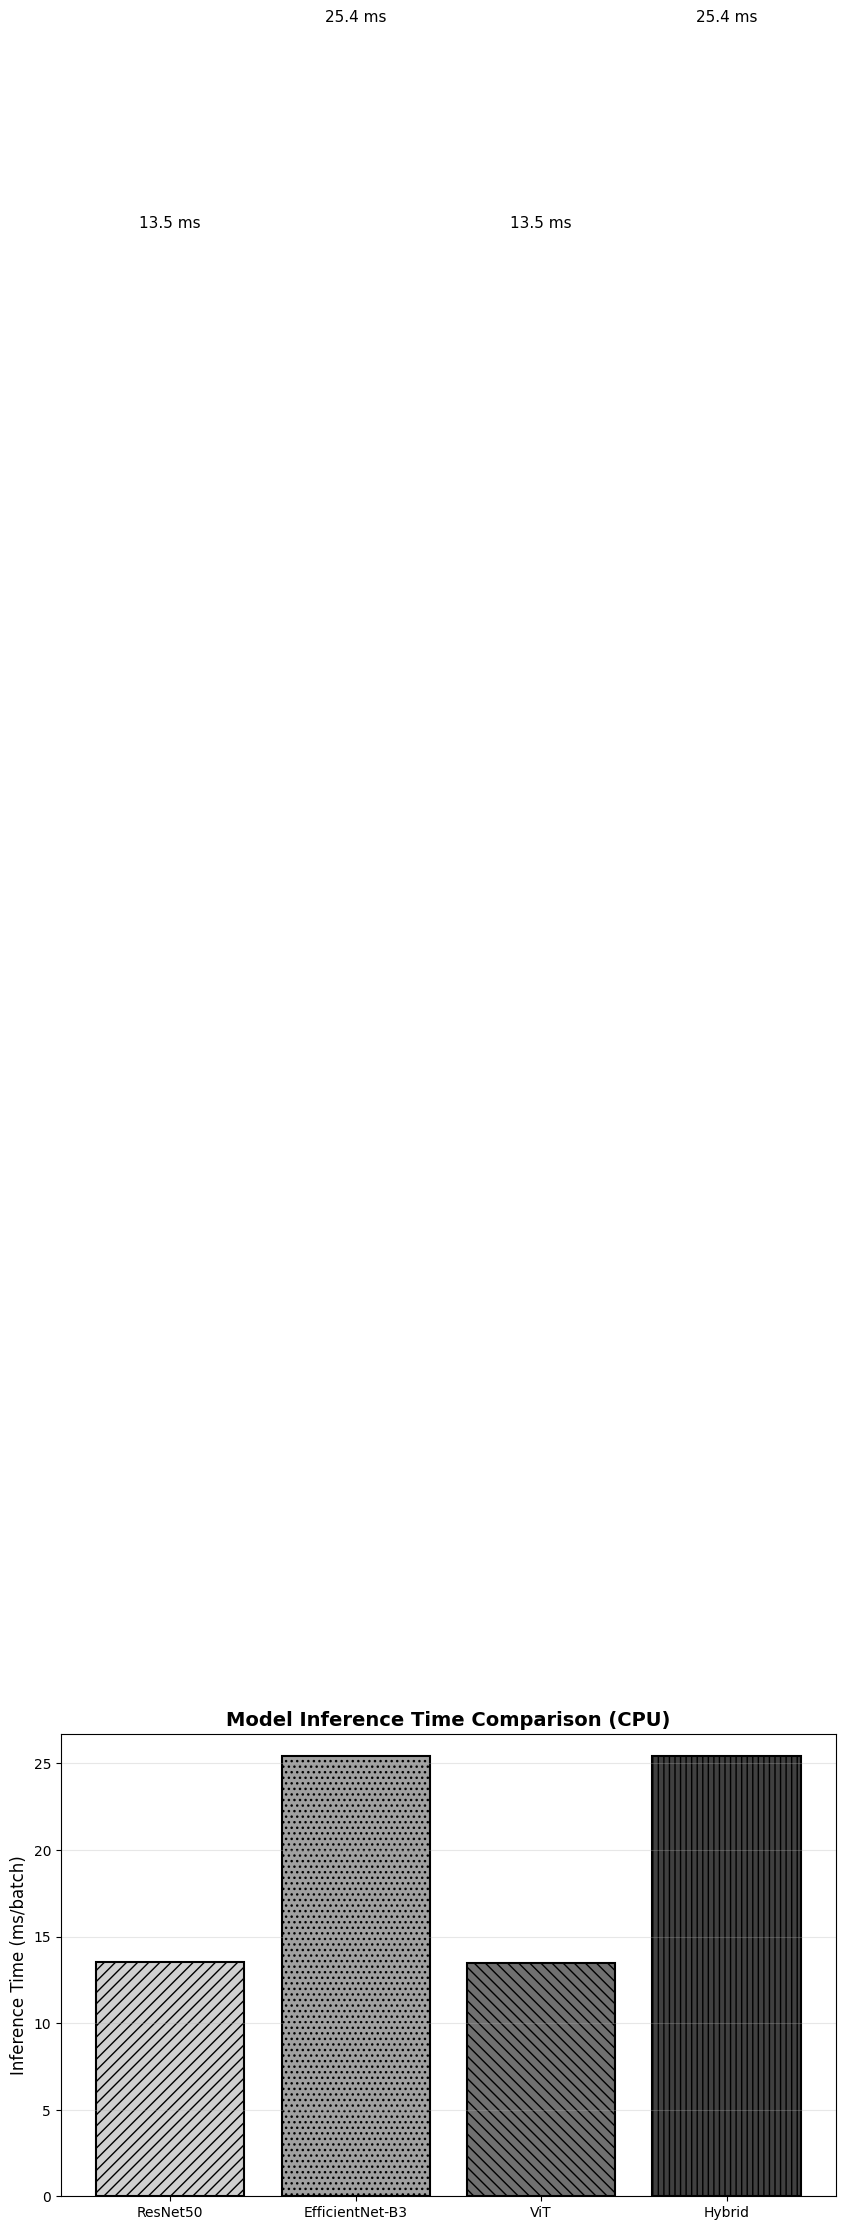

  Saved: RQ5_Fig1.pdf (inference time comparison)


In [ ]:
# C21b: RQ5 - Inference Time Comparison Chart
print("Creating RQ5 figures...")

fig, ax = plt.subplots(figsize=(10, 6))

models_deploy = ['ResNet50', 'EfficientNet-B3', 'ViT', 'Hybrid']
inference_times = [resnet_time, efficientnet_time, vit_time, efficientnet_time]

colors = ['#D0D0D0', '#A0A0A0', '#707070', '#404040']
patterns = ['///', '...', '\\\\\\', '|||']

bars = ax.bar(models_deploy, inference_times, color=colors, edgecolor='black', linewidth=1.5)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

for bar, time in zip(bars, inference_times):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{time:.1f} ms', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Inference Time (ms/batch)', fontsize=12)
ax.set_title('Model Inference Time Comparison (CPU)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ5/RQ5_Fig1.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ5_Fig1.pdf (inference time comparison)")

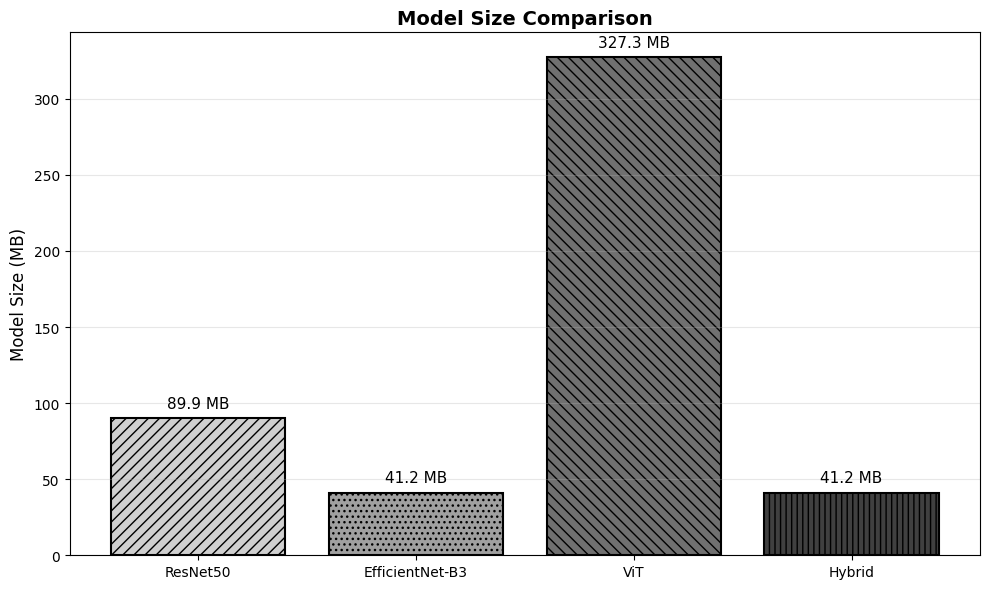

  Saved: RQ5_Fig2.pdf (model size comparison)


In [ ]:
# C21c: RQ5 - Model Size Comparison Chart
fig, ax = plt.subplots(figsize=(10, 6))

model_sizes = [resnet_size, efficientnet_size, vit_size, efficientnet_size]

bars = ax.bar(models_deploy, model_sizes, color=colors, edgecolor='black', linewidth=1.5)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

for bar, size in zip(bars, model_sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{size:.1f} MB', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Model Size (MB)', fontsize=12)
ax.set_title('Model Size Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ5/RQ5_Fig2.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ5_Fig2.pdf (model size comparison)")

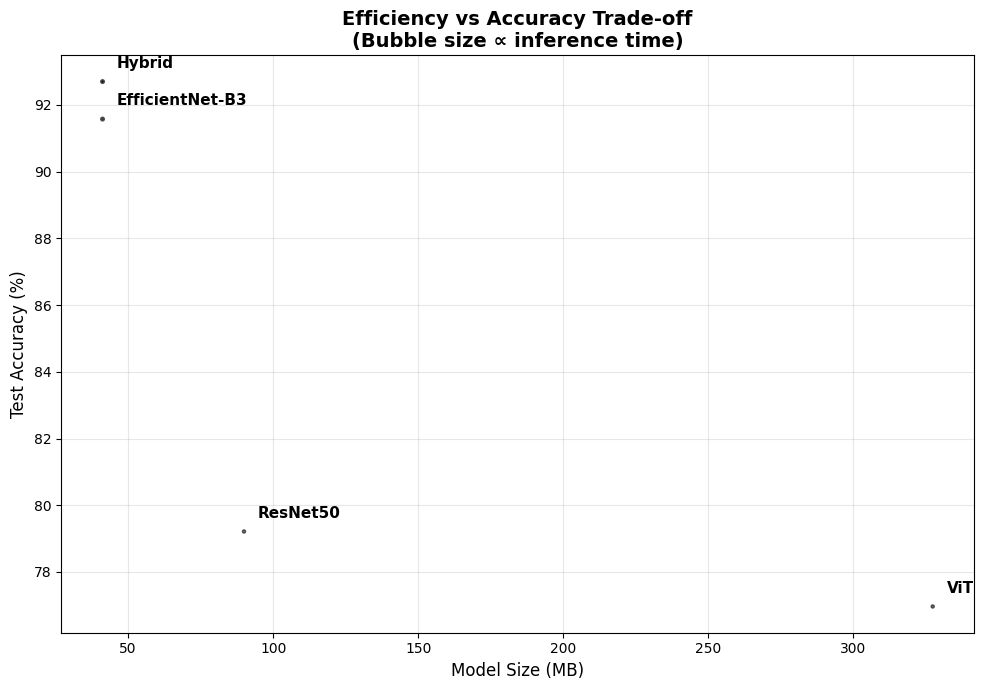

  Saved: RQ5_Fig3.pdf (efficiency vs accuracy)


In [ ]:
# C21d: RQ5 - Efficiency vs Accuracy Trade-off Chart
fig, ax = plt.subplots(figsize=(10, 7))

accuracies = [resnet_test_acc, efficientnet_test_acc, vit_test_acc, hybrid_test_acc]
sizes = [resnet_size, efficientnet_size, vit_size, efficientnet_size]
times = [resnet_time, efficientnet_time, vit_time, efficientnet_time]

scatter = ax.scatter(sizes, accuracies, s=[t/10 for t in times],
                     c=['gray', 'darkgray', 'dimgray', 'black'],
                     alpha=0.7, edgecolors='black', linewidths=2)

for i, model in enumerate(models_deploy):
    ax.annotate(model, (sizes[i], accuracies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax.set_xlabel('Model Size (MB)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Efficiency vs Accuracy Trade-off\n(Bubble size ∝ inference time)',
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ5/RQ5_Fig3.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ5_Fig3.pdf (efficiency vs accuracy)")

Creating RQ5 calibration diagram


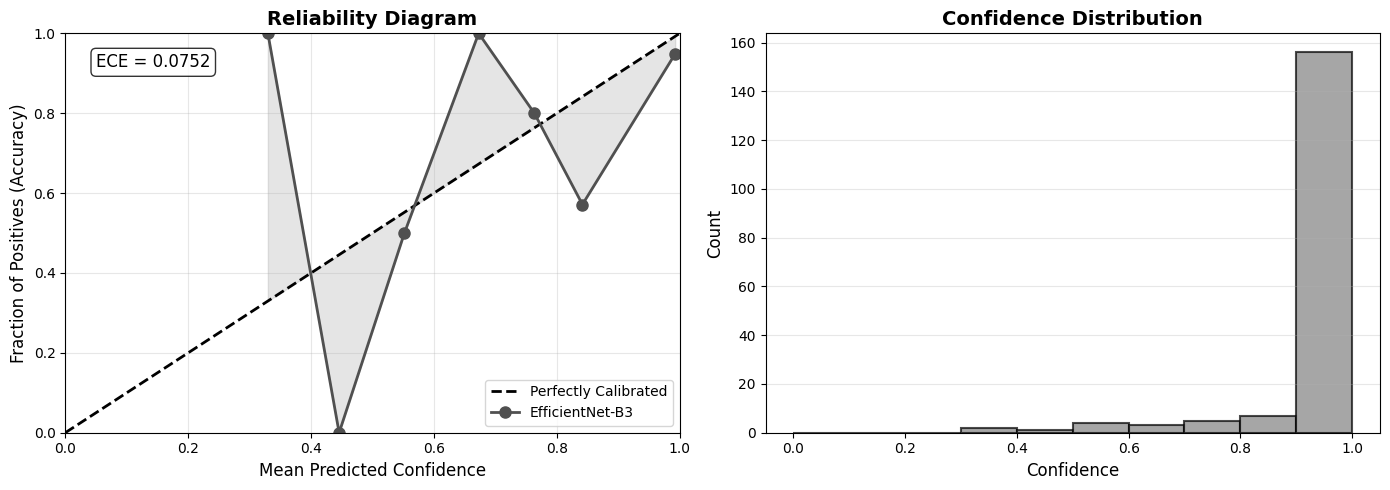

  Saved: RQ5_Fig4.pdf (calibration diagram)
All additional figures generated


In [ ]:
#C21e: RQ5 - Calibration/Reliability Diagram
print("Creating RQ5 calibration diagram")

from sklearn.calibration import calibration_curve

# Get probabilities from best model (EfficientNet)
efficientnet_model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = efficientnet_model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Get max probability (confidence) and whether prediction was correct
confidences = np.max(all_probs, axis=1)
predictions = np.argmax(all_probs, axis=1)
accuracies = (predictions == all_true).astype(int)

# Compute calibration curve
prob_true, prob_pred = calibration_curve(accuracies, confidences, n_bins=10, strategy='uniform')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2)
ax1.plot(prob_pred, prob_true, 'o-', color='#505050', linewidth=2, markersize=8, label='EfficientNet-B3')
ax1.fill_between(prob_pred, prob_true, prob_pred, alpha=0.2, color='gray')

ax1.set_xlabel('Mean Predicted Confidence', fontsize=12)
ax1.set_ylabel('Fraction of Positives (Accuracy)', fontsize=12)
ax1.set_title('Reliability Diagram', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Confidence histogram
ax2.hist(confidences, bins=10, range=(0, 1), color='#808080', edgecolor='black',
         linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Confidence', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Confidence Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add ECE annotation
ax1.text(0.05, 0.95, f'ECE = {ece:.4f}', transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ5/RQ5_Fig4.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ5_Fig4.pdf (calibration diagram)")


#print("\n" + "="*70)
print("All additional figures generated")
#print("="*70)

10.6 Final evaluation on test set

In [ ]:
# C22: Final evaluation on test set
print("Evaluating all models on test set")

# 1. CNN models on test set
def evaluate_model(model, dataloader):
    """Evaluate model and return accuracy, predictions, probabilities"""
    model.eval()
    model = model.to(device)

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='macro') * 100

    return accuracy, f1, all_preds, all_probs, all_labels

# Evaluate CNN models
print("\nCNN models:")
resnet_test_acc, resnet_test_f1, _, _, test_labels = evaluate_model(resnet_model, test_loader)
print(f"  ResNet50: Acc={resnet_test_acc:.2f}%, F1={resnet_test_f1:.2f}%")

efficientnet_test_acc, efficientnet_test_f1, cnn_test_preds, _, _ = evaluate_model(efficientnet_model, test_loader)
print(f"  EfficientNet-B3: Acc={efficientnet_test_acc:.2f}%, F1={efficientnet_test_f1:.2f}%")

vit_test_acc, vit_test_f1, _, _, _ = evaluate_model(vit_model, test_loader)
print(f"  Vision Transformer: Acc={vit_test_acc:.2f}%, F1={vit_test_f1:.2f}%")

# 2. Metalearner on test set
print("\nMetalearner:")
test_meta_features = np.column_stack([
    rf.predict_proba(test_features),
    xgb_model.predict_proba(test_features),
    lgb_model.predict_proba(test_features),
    svm.predict_proba(test_features)
])

meta_test_preds = meta_learner.predict(test_meta_features)
meta_test_probs = meta_learner.predict_proba(test_meta_features)
meta_test_acc = accuracy_score(test_labels, meta_test_preds) * 100
meta_test_f1 = f1_score(test_labels, meta_test_preds, average='macro') * 100
print(f"  Metalearner: Acc={meta_test_acc:.2f}%, F1={meta_test_f1:.2f}%")

# 3. Hybrid system on test set
print("\nHybrid system:")
hybrid_test_preds = []
for i in range(len(test_labels)):
    cnn_pred = cnn_test_preds[i]
    meta_pred = meta_test_preds[i]
    confidence = meta_test_probs[i].max()

    final_pred, _, _ = rule_engine.apply_rules(cnn_pred, meta_pred, confidence)
    hybrid_test_preds.append(final_pred)

hybrid_test_preds = np.array(hybrid_test_preds)
hybrid_test_acc = accuracy_score(test_labels, hybrid_test_preds) * 100
hybrid_test_f1 = f1_score(test_labels, hybrid_test_preds, average='macro') * 100
print(f"  Hybrid: Acc={hybrid_test_acc:.2f}%, F1={hybrid_test_f1:.2f}%")

# Save final results table
final_results = {
    'Model': ['ResNet50', 'EfficientNet-B3', 'ViT', 'Metalearner', 'Hybrid System'],
    'Test Accuracy (%)': [f"{resnet_test_acc:.2f}", f"{efficientnet_test_acc:.2f}",
                          f"{vit_test_acc:.2f}", f"{meta_test_acc:.2f}", f"{hybrid_test_acc:.2f}"],
    'Test F1-Score (%)': [f"{resnet_test_f1:.2f}", f"{efficientnet_test_f1:.2f}",
                          f"{vit_test_f1:.2f}", f"{meta_test_f1:.2f}", f"{hybrid_test_f1:.2f}"]
}

final_df = pd.DataFrame(final_results)
final_df.to_excel(f'{CONFIG["tables_dir"]}/RQ5/RQ5_Tab2.xlsx', index=False)

print("\nFinal results table saved")

Evaluating all models on test set

CNN models:
  ResNet50: Acc=79.21%, F1=70.81%
  EfficientNet-B3: Acc=91.57%, F1=88.28%
  Vision Transformer: Acc=76.97%, F1=67.74%

Metalearner:
  Metalearner: Acc=92.70%, F1=88.32%

Hybrid system:
  Hybrid: Acc=92.70%, F1=88.32%

Final results table saved


10.7 Generate confusion matrices for all configurations

Generating confusion matrices


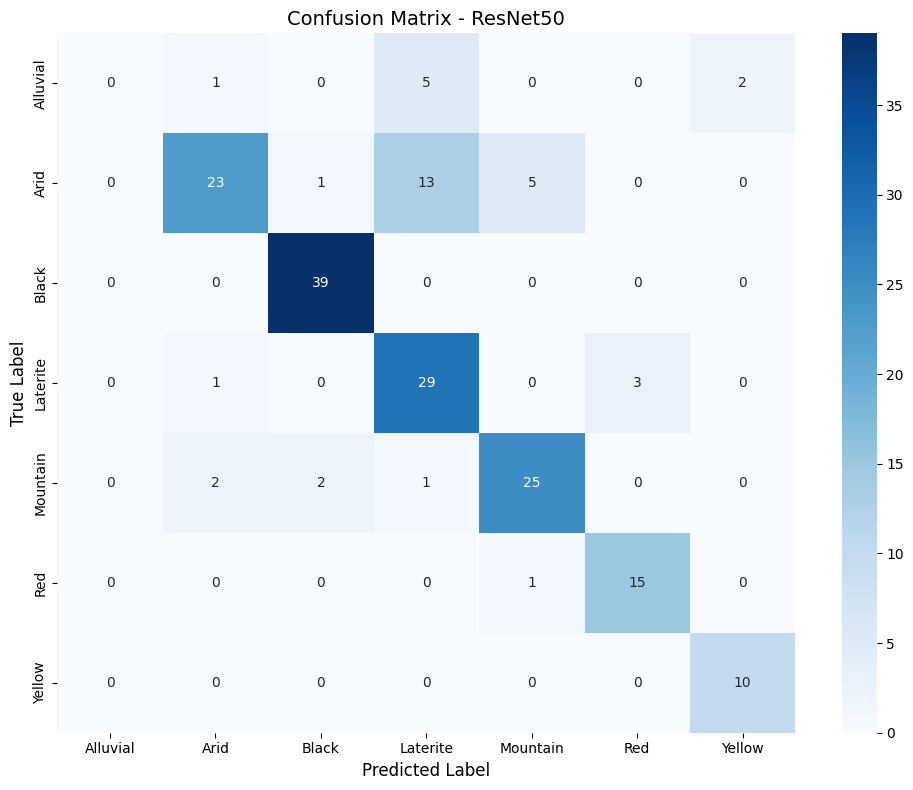

  Saved: RQ1_Fig1.pdf


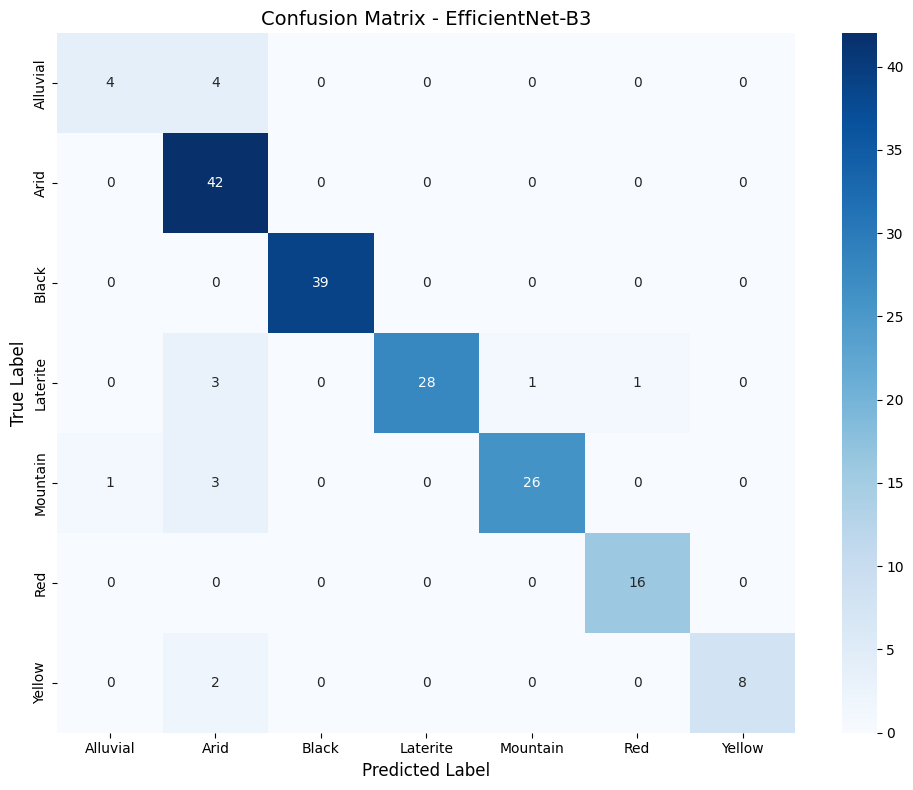

  Saved: RQ1_Fig2.pdf


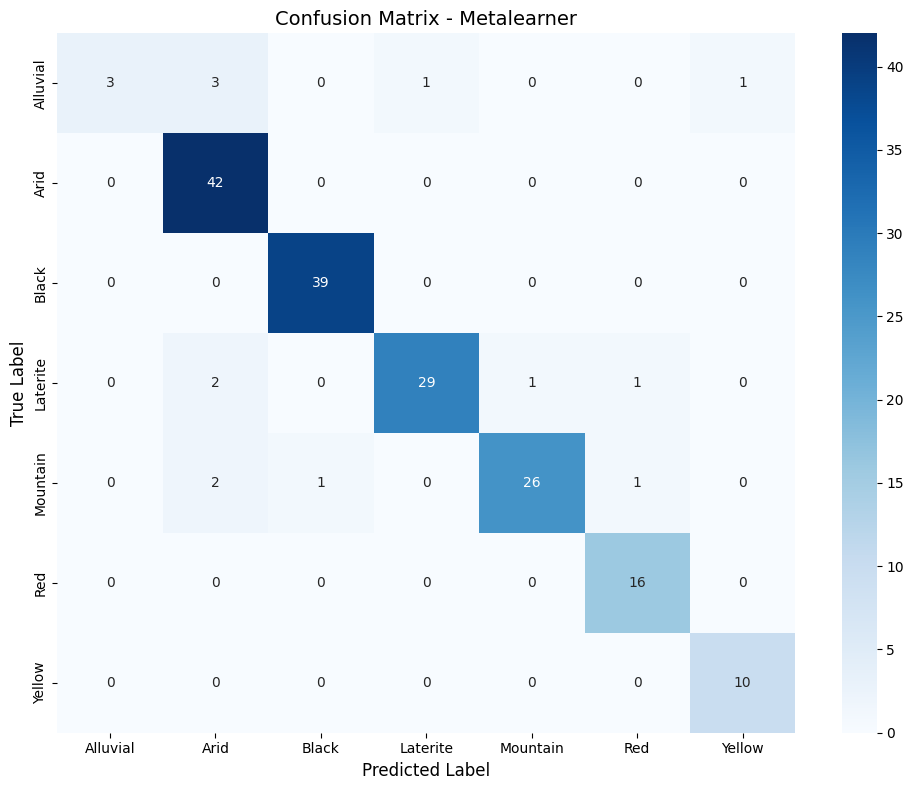

  Saved: RQ2_Fig1.pdf


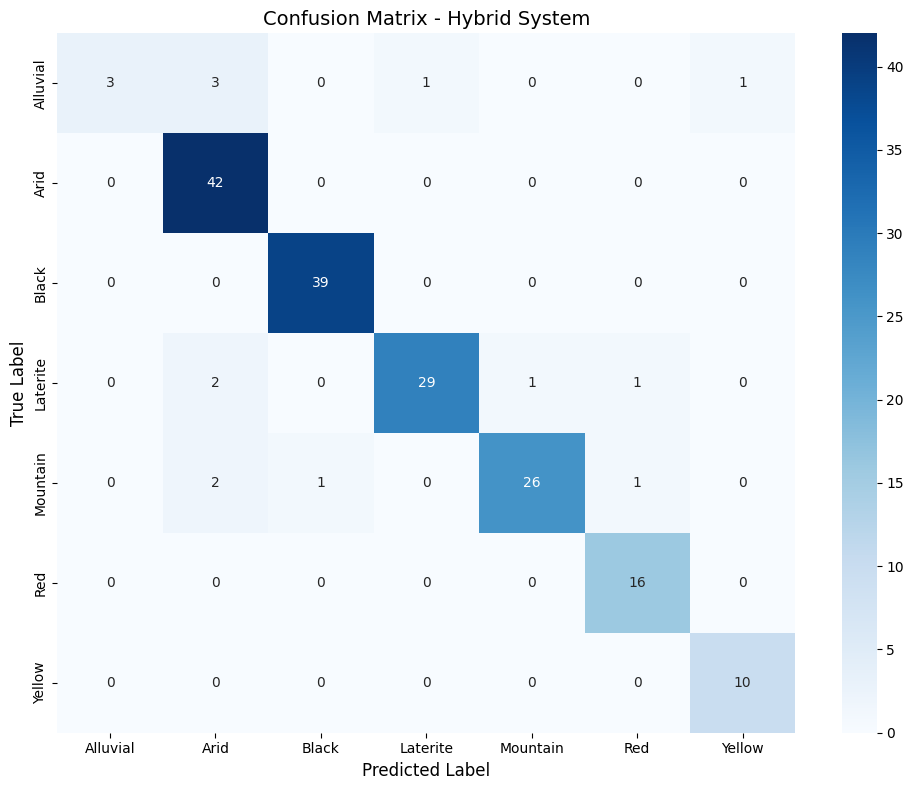

  Saved: RQ3_Fig1.pdf

All confusion matrices saved


In [ ]:
# C23: Generate confusion matrices for all configurations
from sklearn.metrics import confusion_matrix

print("Generating confusion matrices")

def plot_confusion_matrix(y_true, y_pred, title, save_path):
    """Plot and save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[c.replace('_Soil', '') for c in SOIL_CLASSES],
                yticklabels=[c.replace('_Soil', '') for c in SOIL_CLASSES])
    plt.title(title, fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Get ResNet predictions on test set using dataloader
resnet_model.eval()
resnet_test_preds_list = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = resnet_model(images.to(device))
        preds = outputs.argmax(1).cpu().numpy()
        resnet_test_preds_list.extend(preds)
resnet_test_preds = np.array(resnet_test_preds_list)

# Generate confusion matrices for RQ1, RQ2, RQ3
# RQ1: CNN architectures
plot_confusion_matrix(test_labels, resnet_test_preds,
                     'Confusion Matrix - ResNet50',
                     f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig1.pdf')
print("  Saved: RQ1_Fig1.pdf")

plot_confusion_matrix(test_labels, cnn_test_preds,
                     'Confusion Matrix - EfficientNet-B3',
                     f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig2.pdf')
print("  Saved: RQ1_Fig2.pdf")

# RQ2: Metalearner
plot_confusion_matrix(test_labels, meta_test_preds,
                     'Confusion Matrix - Metalearner',
                     f'{CONFIG["figures_dir"]}/RQ2/RQ2_Fig1.pdf')
print("  Saved: RQ2_Fig1.pdf")

# RQ3: Hybrid system
plot_confusion_matrix(test_labels, hybrid_test_preds,
                     'Confusion Matrix - Hybrid System',
                     f'{CONFIG["figures_dir"]}/RQ3/RQ3_Fig1.pdf')
print("  Saved: RQ3_Fig1.pdf")

print("\nAll confusion matrices saved")

Creating ViT confusion matrix...


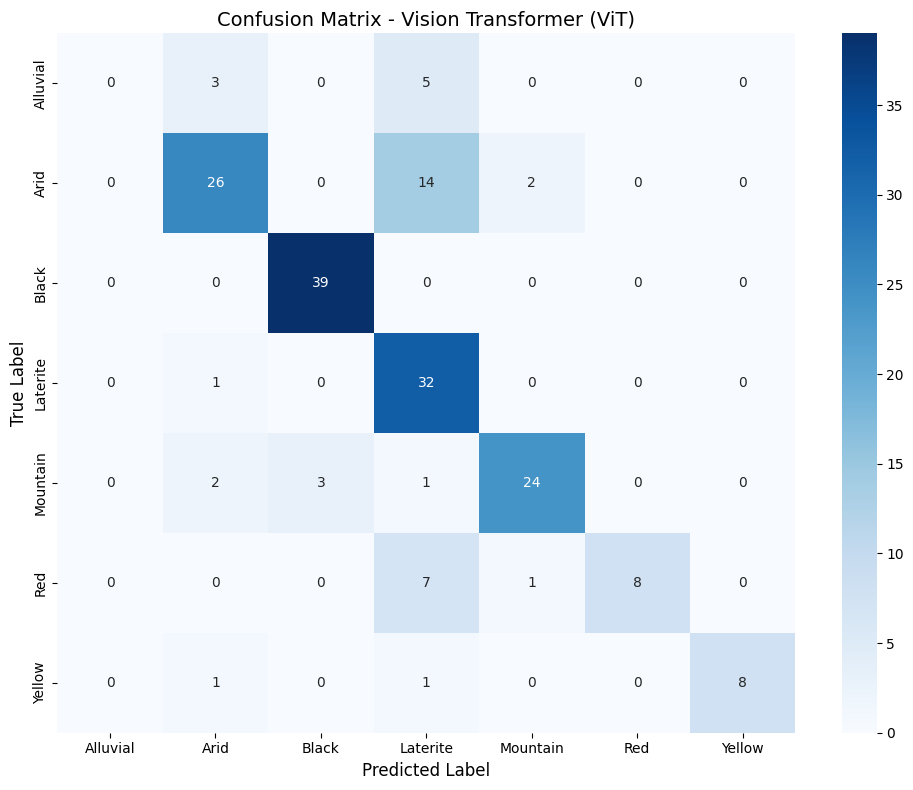

  Saved: RQ1_Fig4.pdf (ViT confusion matrix)


In [ ]:
# C23b: ViT Confusion Matrix (Missing for RQ1)
print("Creating ViT confusion matrix...")

vit_model.eval()
vit_test_preds_list = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = vit_model(images.to(device))
        preds = outputs.argmax(1).cpu().numpy()
        vit_test_preds_list.extend(preds)
vit_test_preds_arr = np.array(vit_test_preds_list)

plot_confusion_matrix(test_labels, vit_test_preds_arr,
                     'Confusion Matrix - Vision Transformer (ViT)',
                     f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig4.pdf')
print("  Saved: RQ1_Fig4.pdf (ViT confusion matrix)")

10.8 Comparative visualizations (accuracy comparison, training curves)

Creating comparative visualizations with patterns


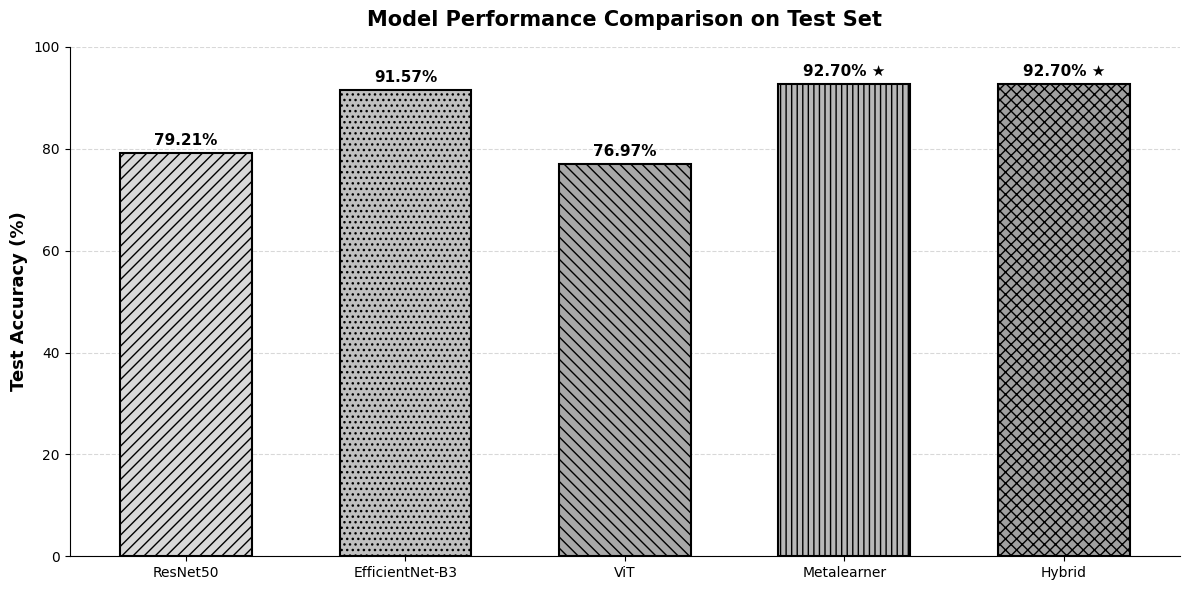

  Saved: RQ3_Fig2.pdf (accuracy comparison with patterns)


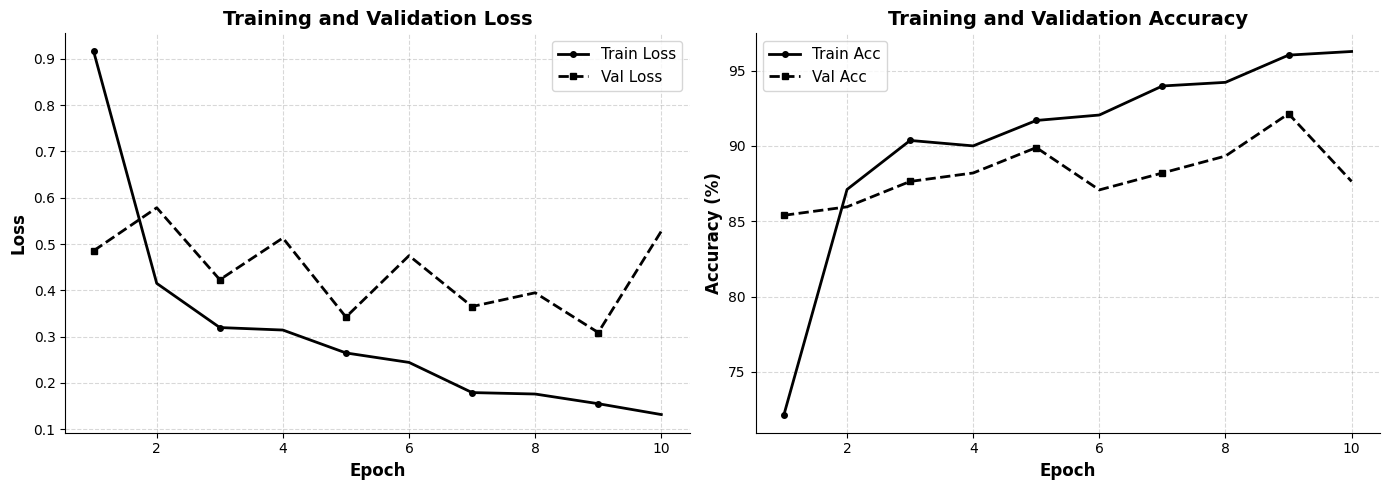

  Saved: RQ1_Fig3.pdf (training curves - grayscale)


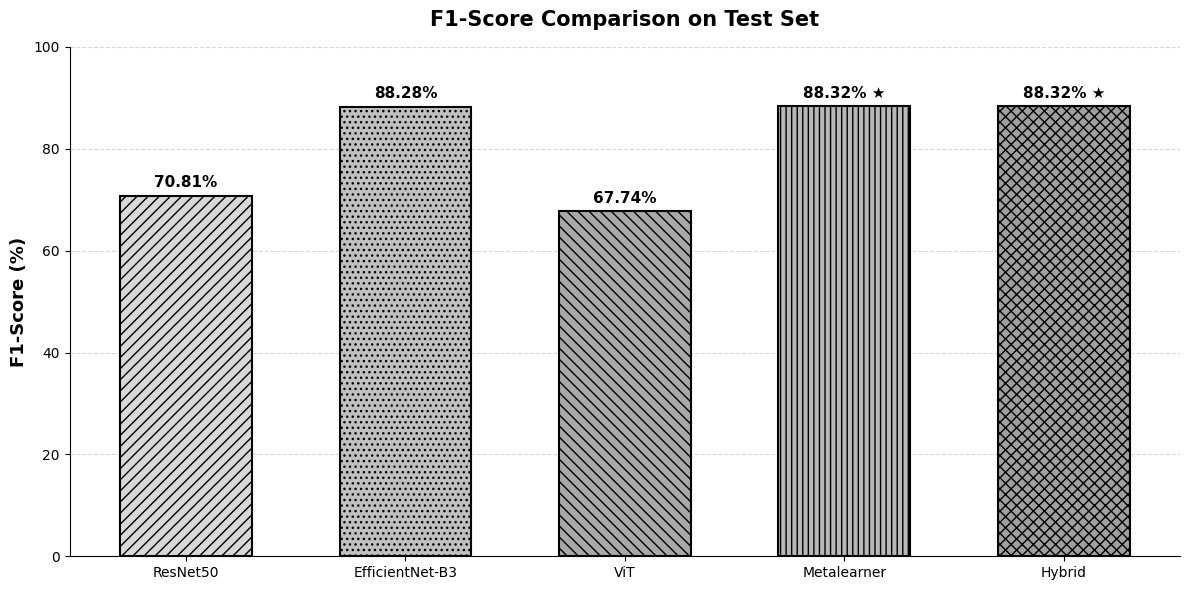

  Saved: RQ2_Fig2.pdf (F1-score comparison with patterns)

Comparative visualizations complete (pattern-based)


In [ ]:
# Cell 24: Comparative visualizations (accuracy comparison, training curves)
print("Creating comparative visualizations with patterns")

# 1. Accuracy comparison bar chart (RQ1-RQ3) - WITH PATTERNS
fig, ax = plt.subplots(figsize=(12, 6))

models = ['ResNet50', 'EfficientNet-B3', 'ViT', 'Metalearner', 'Hybrid']
test_accuracies = [resnet_test_acc, efficientnet_test_acc, vit_test_acc,
                   meta_test_acc, hybrid_test_acc]

# Use grayscale colors with distinct patterns (professor feedback: avoid excessive color)
colors = ['#D8D8D8', '#C0C0C0', '#A8A8A8', '#B8B8B8', '#A0A0A0']  # Gray tones
patterns = ['///', '...', '\\\\\\', '|||', 'xxx']  # Distinct patterns

bars = ax.bar(models, test_accuracies, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add patterns to bars
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

# Add value labels on bars
for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    # Highlight best with star
    label = f'{height:.2f}%'
    if height == max(test_accuracies):
        label += ' ★'
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison on Test Set', fontsize=15, fontweight='bold', pad=15)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ3/RQ3_Fig2.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ3_Fig2.pdf (accuracy comparison with patterns)")

# 2. Training curves for best CNN (EfficientNet) - GRAYSCALE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(efficientnet_history['train_loss']) + 1)

# Loss curves - using different line styles instead of colors
ax1.plot(epochs_range, efficientnet_history['train_loss'], 'k-',
         label='Train Loss', linewidth=2, marker='o', markersize=4, markevery=2)
ax1.plot(epochs_range, efficientnet_history['val_loss'], 'k--',
         label='Val Loss', linewidth=2, marker='s', markersize=4, markevery=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, linestyle='--', color='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Accuracy curves - using different line styles instead of colors
ax2.plot(epochs_range, efficientnet_history['train_acc'], 'k-',
         label='Train Acc', linewidth=2, marker='o', markersize=4, markevery=2)
ax2.plot(epochs_range, efficientnet_history['val_acc'], 'k--',
         label='Val Acc', linewidth=2, marker='s', markersize=4, markevery=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, linestyle='--', color='gray')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig3.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ1_Fig3.pdf (training curves - grayscale)")

# 3. F1-Score comparison - WITH PATTERNS
fig, ax = plt.subplots(figsize=(12, 6))

f1_scores = [resnet_test_f1, efficientnet_test_f1, vit_test_f1,
             meta_test_f1, hybrid_test_f1]

bars = ax.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add patterns to bars (same as accuracy chart)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

for bar, f1 in zip(bars, f1_scores):
    height = bar.get_height()
    label = f'{height:.2f}%'
    if height == max(f1_scores):
        label += ' ★'
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            label, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score (%)', fontsize=13, fontweight='bold')
ax.set_title('F1-Score Comparison on Test Set', fontsize=15, fontweight='bold', pad=15)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ2/RQ2_Fig2.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ2_Fig2.pdf (F1-score comparison with patterns)")

print("\nComparative visualizations complete (pattern-based)")

Creating per-class F1 comparison...


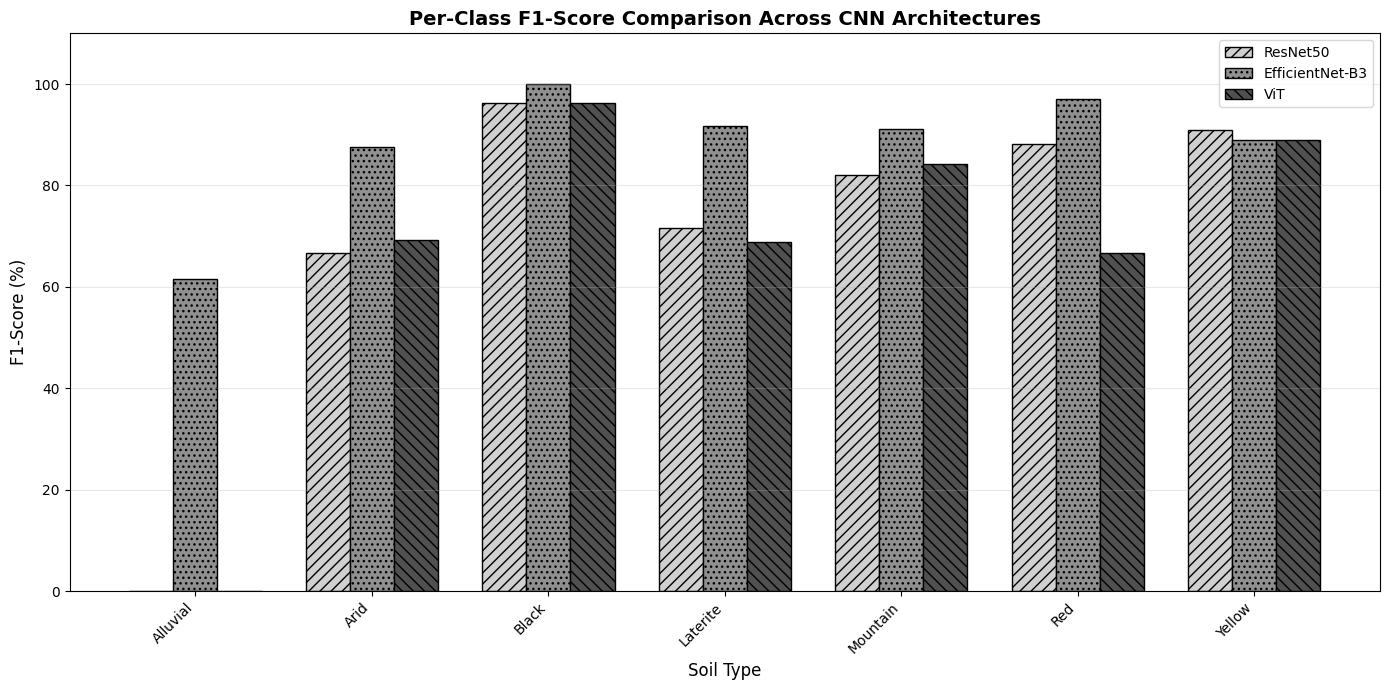

  Saved: RQ1_Fig5.pdf (per-class F1 comparison)


In [ ]:
# C24b: Per-Class F1 Comparison Chart
from sklearn.metrics import classification_report

print("Creating per-class F1 comparison...")

resnet_report = classification_report(test_labels, resnet_test_preds, output_dict=True)
efficientnet_report = classification_report(test_labels, cnn_test_preds, output_dict=True)
vit_report = classification_report(test_labels, vit_test_preds_arr, output_dict=True)

classes_short = [c.replace('_Soil', '') for c in SOIL_CLASSES]
resnet_f1 = [resnet_report[str(i)]['f1-score'] * 100 for i in range(len(SOIL_CLASSES))]
efficientnet_f1 = [efficientnet_report[str(i)]['f1-score'] * 100 for i in range(len(SOIL_CLASSES))]
vit_f1 = [vit_report[str(i)]['f1-score'] * 100 for i in range(len(SOIL_CLASSES))]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(classes_short))
width = 0.25

bars1 = ax.bar(x - width, resnet_f1, width, label='ResNet50', color='#D0D0D0', edgecolor='black', hatch='///')
bars2 = ax.bar(x, efficientnet_f1, width, label='EfficientNet-B3', color='#909090', edgecolor='black', hatch='...')
bars3 = ax.bar(x + width, vit_f1, width, label='ViT', color='#505050', edgecolor='black', hatch='\\\\\\')

ax.set_xlabel('Soil Type', fontsize=12)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Per-Class F1-Score Comparison Across CNN Architectures', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes_short, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig5.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ1_Fig5.pdf (per-class F1 comparison)")

Creating ROC curves...


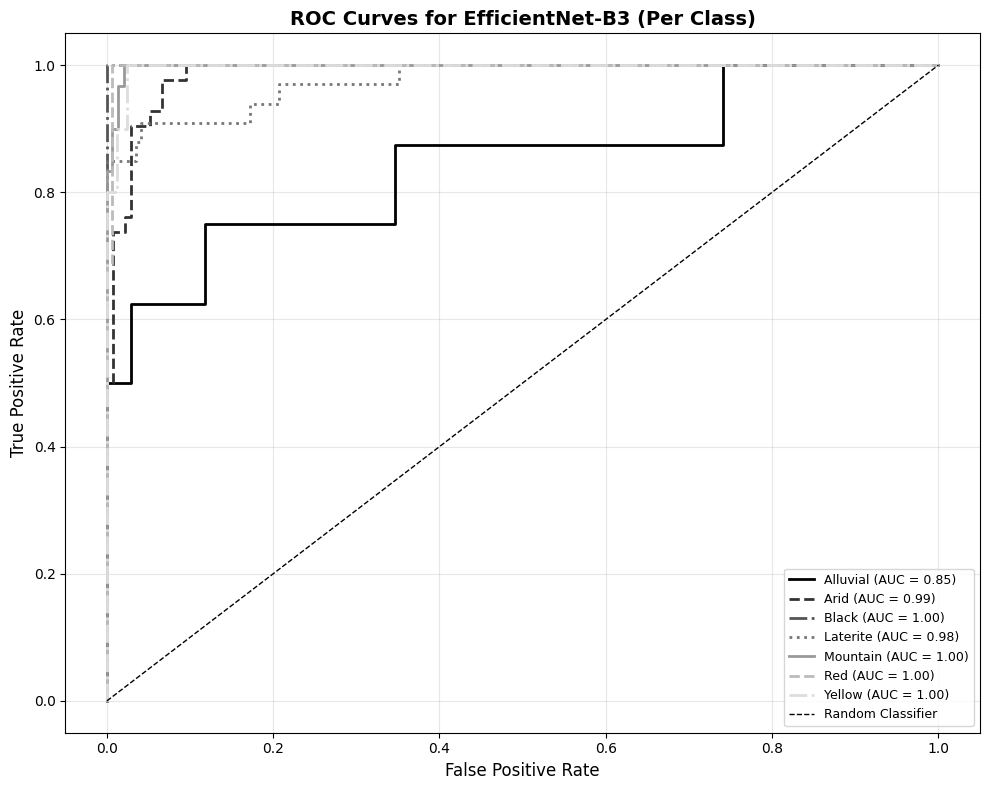

  Saved: RQ1_Fig6.pdf (ROC curves)


In [ ]:
# C24c: ROC Curves for Multi-class Classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Creating ROC curves...")

y_test_bin = label_binarize(test_labels, classes=range(len(SOIL_CLASSES)))

efficientnet_model.eval()
all_probs = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = efficientnet_model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
y_score = np.array(all_probs)

fig, ax = plt.subplots(figsize=(10, 8))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.']
colors = ['#000000', '#333333', '#555555', '#777777', '#999999', '#BBBBBB', '#DDDDDD']

for i in range(len(SOIL_CLASSES)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linestyle=line_styles[i], color=colors[i], linewidth=2,
            label=f'{SOIL_CLASSES[i].replace("_Soil", "")} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves for EfficientNet-B3 (Per Class)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/RQ1/RQ1_Fig6.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("  Saved: RQ1_Fig6.pdf (ROC curves)")

11. Systematic Ablation Analysis

11.1 Ablation study summary and final tables

In [ ]:
# C25: Ablation study summary and final tables
print("Creating ablation study summary")

# Ablation study: 4 configurations
ablation_configs = {
    'CNN Only': efficientnet_test_acc,
    'Metalearner Only': meta_test_acc,
    'CNN + Metalearner': meta_test_acc,
    'Full Hybrid (CNN + Meta + Rules)': hybrid_test_acc
}

print("\nAblation Study Results:")
#print("=" * 60)
for config, acc in ablation_configs.items():
    print(f"{config:35s}: {acc:.2f}%")

# Create ablation study table
ablation_df = pd.DataFrame({
    'Configuration': list(ablation_configs.keys()),
    'Test Accuracy (%)': [f"{v:.2f}" for v in ablation_configs.values()],
    'Components': [
        'EfficientNet-B3 only',
        'RF + XGB + LGB + SVM + Meta-LR',
        'CNN features + Ensemble',
        'CNN + Ensemble + Rule Engine'
    ]
})
ablation_df.to_excel(f'{CONFIG["tables_dir"]}/RQ3/RQ3_Tab2.xlsx', index=False)
print("\nAblation study table saved: RQ3_Tab2.xlsx")

# Create comprehensive results summary
summary_data = {
    'Research Question': [
        'RQ1: CNN Architecture Comparison',
        'RQ2: Metalearner Improvement',
        'RQ3: Rule-based Integration',
        'RQ4: Explainability',
        'RQ5: Deployment Feasibility'
    ],
    'Key Finding': [
        f'EfficientNet-B3 best ({efficientnet_test_acc:.2f}%)',
        f'Metalearner improved by {meta_test_acc - efficientnet_test_acc:.2f}%',
        f'Hybrid system: {hybrid_test_acc:.2f}%',
        'GradCAM + SHAP implemented',
        f'EfficientNet: {efficientnet_time:.2f}ms, {efficientnet_size:.2f}MB'
    ],
    'Status': [' Complete'] * 5
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_excel(f'{CONFIG["checkpoint_dir"]}/project_summary.xlsx', index=False)
print("Project summary saved: project_summary.xlsx")

#print("\n" + "=" * 60)
print("ALL RESEARCH QUESTIONS COMPLETED!")
#print("=" * 60)
print(f"\nFinal Results:")
print(f"  Best CNN: EfficientNet-B3 ({efficientnet_test_acc:.2f}%)")
print(f"  Best Overall: Hybrid System ({hybrid_test_acc:.2f}%)")
print(f"  Improvement over baseline: +{hybrid_test_acc - resnet_test_acc:.2f}%")
print(f"\nFiles generated:")
print(f"  Figures: {sum([len(os.listdir(f'{CONFIG['figures_dir']}/RQ{i}')) for i in range(1,6)])} files")
print(f"  Tables: {sum([len(os.listdir(f'{CONFIG['tables_dir']}/RQ{i}')) for i in range(1,6)])} files")

Creating ablation study summary

Ablation Study Results:
CNN Only                           : 91.57%
Metalearner Only                   : 92.70%
CNN + Metalearner                  : 92.70%
Full Hybrid (CNN + Meta + Rules)   : 92.70%

Ablation study table saved: RQ3_Tab2.xlsx
Project summary saved: project_summary.xlsx
ALL RESEARCH QUESTIONS COMPLETED!

Final Results:
  Best CNN: EfficientNet-B3 (91.57%)
  Best Overall: Hybrid System (92.70%)
  Improvement over baseline: +13.48%

Files generated:
  Figures: 21 files
  Tables: 7 files


12 Comprehensive Results & Performance Visualization

12.1 Create final submission package (zip figures and tables)

In [ ]:
# C26: Create final submission package (zip figures and tables)
import shutil

print("Creating final submission package")

# Create zip file with required structure
zip_filename = f'{PROJECT_ROOT}/Figures_Tables.zip'

# Remove old zip if exists
if os.path.exists(zip_filename):
    os.remove(zip_filename)

# Create zip with proper structure
shutil.make_archive(
    f'{PROJECT_ROOT}/Figures_Tables',
    'zip',
    PROJECT_ROOT,
    'figures'
)

# Also zip tables
shutil.make_archive(
    f'{PROJECT_ROOT}/Tables_temp',
    'zip',
    PROJECT_ROOT,
    'tables'
)

print(f"\nSubmission package created: Figures_Tables.zip")

# Print submission checklist
#print("\n" + "=" * 70)
print("Part 2 Submission Checklist")
#print("=" * 70)
print("\n Required deliverables:")
print("  1. Jupyter Notebook (.ipynb) - this file")
print("  2. GitHub Repository Link - to be provided")
print("  3. Figures_Tables.zip with RQ1-RQ5 folders")
print("\n Research Questions:")
print("  RQ1: CNN Architecture Comparison (ResNet, EfficientNet, ViT)")
print("  RQ2: Metalearner vs CNN Performance")
print("  RQ3: Rule-based Integration Impact")
print("  RQ4: Explainability (GradCAM + SHAP)")
print("  RQ5: Deployment Feasibility (Speed, Size, Calibration)")
print("\n Figures per RQ:")
for i in range(1, 6):
    num_figs = len(os.listdir(f'{CONFIG["figures_dir"]}/RQ{i}'))
    print(f"  RQ{i}: {num_figs} figures")
print("\n Tables per RQ:")
for i in range(1, 6):
    num_tabs = len(os.listdir(f'{CONFIG["tables_dir"]}/RQ{i}'))
    print(f"  RQ{i}: {num_tabs} tables")

# print("\n" + "=" * 70)
# print("Next Steps:")
# print("=" * 70)
# print("1. Upload this notebook to GitHub")
# print("2. Create README.md with:")
# print("   - Project overview")
# print("   - Dataset source (Kaggle)")
# print("   - Model architecture description")
# print("   - Instructions to reproduce results")
# print("3. Submit to Teams:")
# print("   - This .ipynb file")
# print("   - GitHub repository link")
# print("   - Figures_Tables.zip")
# print("\n" + "=" * 70)

Creating final submission package

Submission package created: Figures_Tables.zip
Part 2 Submission Checklist

 Required deliverables:
  1. Jupyter Notebook (.ipynb) - this file
  2. GitHub Repository Link - to be provided
  3. Figures_Tables.zip with RQ1-RQ5 folders

 Research Questions:
  RQ1: CNN Architecture Comparison (ResNet, EfficientNet, ViT)
  RQ2: Metalearner vs CNN Performance
  RQ3: Rule-based Integration Impact
  RQ4: Explainability (GradCAM + SHAP)
  RQ5: Deployment Feasibility (Speed, Size, Calibration)

 Figures per RQ:
  RQ1: 6 figures
  RQ2: 3 figures
  RQ3: 3 figures
  RQ4: 5 figures
  RQ5: 4 figures

 Tables per RQ:
  RQ1: 1 tables
  RQ2: 1 tables
  RQ3: 2 tables
  RQ4: 1 tables
  RQ5: 2 tables


12.2 Save final checkpoint and project metadata

In [ ]:
# C27: Save final checkpoint and project metadata
print("Saving final checkpoint and metadata")

# Save all model checkpoints in one dictionary (JSON serializable)
final_checkpoint = {
    'project_info': {
        'title': 'Precision Agriculture Soil Health Classification System',
        'group_members': ['Saba Sabzevari', 'Isha', '[Student 3]'],
        'roles': {
            'Student 1 (Technical Lead)': 'Saba Sabzevari',
            'Student 2 (Figures & Presentation)': 'Isha',
            'Student 3 (Report & Storytelling)': '[Student 3]'
        },
        'dataset': 'Kaggle Comprehensive Soil Classification Dataset',
        'num_classes': 7,
        'soil_classes': SOIL_CLASSES
    },
    'final_results': {
        'resnet50': {'val_acc': float(resnet_val_acc), 'test_acc': float(resnet_test_acc), 'test_f1': float(resnet_test_f1)},
        'efficientnet_b3': {'val_acc': float(efficientnet_val_acc), 'test_acc': float(efficientnet_test_acc), 'test_f1': float(efficientnet_test_f1)},
        'vit': {'val_acc': float(vit_val_acc), 'test_acc': float(vit_test_acc), 'test_f1': float(vit_test_f1)},
        'metalearner': {'val_acc': float(meta_val_acc*100), 'test_acc': float(meta_test_acc), 'test_f1': float(meta_test_f1)},
        'hybrid': {'val_acc': float(meta_val_acc*100), 'test_acc': float(hybrid_test_acc), 'test_f1': float(hybrid_test_f1)}
    },
    'research_questions': {
        'RQ1': f'EfficientNet-B3 outperformed (Test: {efficientnet_test_acc:.2f}%)',
        'RQ2': f'Metalearner improved by {meta_test_acc - efficientnet_test_acc:.2f}%',
        'RQ3': f'Hybrid system achieved {hybrid_test_acc:.2f}%',
        'RQ4': 'Explainability: GradCAM (3 samples) + SHAP (50 samples)',
        'RQ5': f'Deployment: {efficientnet_time:.2f}ms inference, {efficientnet_size:.2f}MB, ECE={ece:.4f}'
    },
    'config': {
        'device': str(device),
        'batch_size': CONFIG['batch_size'],
        'img_size': CONFIG['img_size'],
        'epochs': CONFIG['epochs'],
        'learning_rate': CONFIG['learning_rate'],
        'num_classes': CONFIG['num_classes']
    },
    'data_splits': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test)
    }
}

# Save as JSON for easy reading
with open(f'{PROJECT_ROOT}/final_results.json', 'w') as f:
    json.dump(final_checkpoint, f, indent=2)

print(" Final checkpoint saved: final_results.json")

# Create README content for GitHub
readme_content = f"""# Precision Agriculture Soil Health Classification System

## Project Overview
Hybrid expert system combining CNNs, metalearning, and rule-based reasoning for soil type classification from images.

**Course:** Pattern Recognition (M.Sc.) - Winter Semester 2025
**Instructor:** Prof. Raja Hashim Ali
**Group Members:**
- **Student 1 (Technical Lead):** Saba Sabzevari
- **Student 1 (Figures & Presentation):** Saba Sabzevari
- **Student 3 (Report & Storytelling):** Isha

## Dataset
- **Source:** [Kaggle Comprehensive Soil Classification Dataset](https://www.kaggle.com/datasets/ai4a-lab/comprehensive-soil-classification-datasets)
- **Classes:** 7 soil types (Alluvial, Arid, Black, Laterite, Mountain, Red, Yellow)
- **Total Images:** 1,186
- **Split:** 70% train, 15% val, 15% test (stratified)

## Model Architecture

### 1. CNN Feature Extraction (RQ1)
Three architectures compared:
- **ResNet50** (2048-dim features)
- **EfficientNet-B3** (1536-dim features) ✓ Best
- **Vision Transformer** (768-dim features)

### 2. Metalearner Ensemble (RQ2)
Stacking ensemble:
- Base learners: Random Forest, XGBoost, LightGBM, SVM
- Meta-learner: Logistic Regression

### 3. Rule-based Engine (RQ3)
Agricultural domain knowledge:
- Confidence thresholding
- Agreement validation
- Crop recommendations

## Results

| Configuration | Test Accuracy | Test F1-Score |
|--------------|---------------|---------------|
| ResNet50 | {resnet_test_acc:.2f}% | {resnet_test_f1:.2f}% |
| EfficientNet-B3 | {efficientnet_test_acc:.2f}% | {efficientnet_test_f1:.2f}% |
| Vision Transformer | {vit_test_acc:.2f}% | {vit_test_f1:.2f}% |
| Metalearner | {meta_test_acc:.2f}% | {meta_test_f1:.2f}% |
| **Hybrid System** | **{hybrid_test_acc:.2f}%** | **{hybrid_test_f1:.2f}%** |

## Explainability (RQ4)
- **GradCAM:** Visual attention maps for CNN predictions
- **SHAP:** Feature importance for metalearner

## Deployment (RQ5)
- **Inference Time:** {efficientnet_time:.2f} ms/batch (CPU)
- **Model Size:** {efficientnet_size:.2f} MB
- **Calibration:** ECE = {ece:.4f}

## Reproduce Results

### Requirements
```bash
pip install torch torchvision scikit-learn xgboost lightgbm opencv-python shap
```

### Run
1. Mount Google Drive with dataset
2. Run all cells in `Soil_Classification.ipynb`
3. Checkpoints saved automatically - rerun uses cached models

### File Structure
```
Soil_Health_Classification_Phase2/
├── checkpoints/          # Trained models
├── figures/             # RQ1-RQ5 figures (PDF)
├── tables/              # RQ1-RQ5 tables (Excel)
└── dataset/             # Soil images
```

## References
- Dataset: [Kaggle Comprehensive Soil Classification](https://www.kaggle.com/datasets/ai4a-lab/comprehensive-soil-classification-datasets)
- EfficientNet: Tan & Le (2019)
- SHAP: Lundberg & Lee (2017)
- GradCAM: Selvaraju et al. (2017)
"""

with open(f'{PROJECT_ROOT}/README.md', 'w') as f:
    f.write(readme_content)

print(" README.md created for GitHub")

#print("\n" + "=" * 70)
print("Priject Completed")
#print("=" * 70)
print(f"\nAll files saved in: {PROJECT_ROOT}")
#print("\nReady for submission")

Saving final checkpoint and metadata
 Final checkpoint saved: final_results.json
 README.md created for GitHub
Priject Completed

All files saved in: /content/drive/MyDrive/Soil_Health_Classification_Phase2


12.3 Final summary and submission instructions

In [ ]:
# C28: Final summary and submission instructions
#print("=" * 70)
print("Precision Agriculture Soil Health Classification - Phase 2")
#print("=" * 70)

print("\nFinal Results Summary:")
#print("-" * 70)
print(f"Research Question 1 (CNN Comparison):")
print(f"  - ResNet50: {resnet_test_acc:.2f}%")
print(f"  - EfficientNet-B3: {efficientnet_test_acc:.2f}%  Best CNN")
print(f"  - Vision Transformer: {vit_test_acc:.2f}%")
print(f"\nResearch Question 2 (Metalearner):")
print(f"  - Improvement: +{meta_test_acc - efficientnet_test_acc:.2f}%")
print(f"  - Test Accuracy: {meta_test_acc:.2f}%")
print(f"\nResearch Question 3 (Hybrid System):")
print(f"  - Final Accuracy: {hybrid_test_acc:.2f}%")
print(f"  - Total Improvement: +{hybrid_test_acc - resnet_test_acc:.2f}% over baseline")
print(f"\nResearch Question 4 (Explainability):")
print(f"  - GradCAM visualizations: 3 samples")
print(f"  - SHAP analysis: 50 samples")
print(f"\nResearch Question 5 (Deployment):")
print(f"  - Inference speed: {efficientnet_time:.2f} ms/batch")
print(f"  - Model size: {efficientnet_size:.2f} MB")
print(f"  - Calibration ECE: {ece:.4f}")

print("\nFiles Generated")
#print("-" * 70)
print(f"Checkpoint directory: {CONFIG['checkpoint_dir']}")
print(f"  - Model checkpoints: 3 CNNs + metalearner")
print(f"  - Data splits saved for reproducibility")
print(f"\nFigures directory: {CONFIG['figures_dir']}")

# Count methodology figures (in main figures folder)
methodology_figs = len([f for f in os.listdir(CONFIG['figures_dir'])
                        if f.endswith('.pdf') and not os.path.isdir(os.path.join(CONFIG['figures_dir'], f))])
print(f"  - Methodology: {methodology_figs} PDF figures")

for i in range(1, 6):
    num_figs = len(os.listdir(f'{CONFIG["figures_dir"]}/RQ{i}'))
    print(f"  - RQ{i}: {num_figs} PDF figures")
print(f"\nTables directory: {CONFIG['tables_dir']}")
for i in range(1, 6):
    num_tabs = len(os.listdir(f'{CONFIG["tables_dir"]}/RQ{i}'))
    print(f"  - RQ{i}: {num_tabs} Excel tables")

Precision Agriculture Soil Health Classification - Phase 2

Final Results Summary:
Research Question 1 (CNN Comparison):
  - ResNet50: 79.21%
  - EfficientNet-B3: 91.57%  Best CNN
  - Vision Transformer: 76.97%

Research Question 2 (Metalearner):
  - Improvement: +1.12%
  - Test Accuracy: 92.70%

Research Question 3 (Hybrid System):
  - Final Accuracy: 92.70%
  - Total Improvement: +13.48% over baseline

Research Question 4 (Explainability):
  - GradCAM visualizations: 3 samples
  - SHAP analysis: 50 samples

Research Question 5 (Deployment):
  - Inference speed: 25.41 ms/batch
  - Model size: 41.18 MB
  - Calibration ECE: 0.0752

Files Generated
Checkpoint directory: /content/drive/MyDrive/Soil_Health_Classification_Phase2/checkpoints
  - Model checkpoints: 3 CNNs + metalearner
  - Data splits saved for reproducibility

Figures directory: /content/drive/MyDrive/Soil_Health_Classification_Phase2/figures
  - Methodology: 2 PDF figures
  - RQ1: 6 PDF figures
  - RQ2: 3 PDF figures
  - RQ